In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from pathlib import Path
import sys
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader



# Постановка задачи

Требуется построить модель нормального поведения ПК пользователя на основе собранных данных.

Модель обучается только на примерах нормальной работы и должна восстанавливать такие состояния с малой ошибкой восстановления.

Предполагается, что неизвестные ранее аномальные состояния не будут соответствовать изученному распределению нормальных данных, вследствие чего ошибка реконструкции возрастет.

Обнаружение аномалии осуществляется путем сравнения ошибки реконструкции с выбранным порогом.

# Подготовка аномалий

Был подготовлен датасет содержащий в большей мере аномальные следы поведения user

In [2]:
file_path = Path.cwd().parent / 'data' / 'anomaly.csv'

anomaly = pd.read_csv(file_path)
anomaly.sample(10)

,timestamp,cpu_percent,memory_percent,swap_percent,disk_usage_percent,disk_read_bytes_delta,disk_write_bytes_delta,disk_read_count_delta,disk_write_count_delta,bytes_sent_delta,...,process_count,new_processes,new_unique_processes,tcp_total,tcp_established,tcp_time_wait,tcp_close_wait,tcp_listen,hour,weekday
198,2026-08-06 01:59:57,34.0,91.8,7.3,23.3,371888128,19744768,2943,1198,888957,...,223,6,0,192,139,20,4,24,1,3
102,2026-08-06 01:51:55,2.0,74.7,4.6,23.3,114688,36864,3,7,135552,...,210,0,0,57,21,10,1,24,1,3
156,2026-08-06 01:56:26,4.4,63.5,4.0,23.3,16384,954368,1,98,1393695,...,194,0,0,217,72,44,58,22,1,3
128,2026-08-06 01:54:06,8.9,61.5,4.2,23.3,2187264,2416640,46,142,341009,...,192,0,0,145,118,0,1,22,1,3
9,2026-08-06 01:44:09,6.4,92.9,6.6,22.7,2717184,1523712,70,191,0,...,215,1,0,70,33,4,3,30,1,3
199,2026-08-06 02:00:02,34.1,91.8,8.5,23.3,60018176,124237312,1799,1679,935113,...,226,3,0,209,159,19,5,24,2,3
61,2026-08-06 01:48:30,13.1,67.6,3.0,23.2,232800256,44572672,1000,139,32438,...,186,0,0,34,7,3,2,22,1,3
40,2026-08-06 01:46:44,13.8,90.9,7.8,22.9,174070784,166744064,242,163,3586,...,209,0,0,57,24,2,1,30,1,3
27,2026-08-06 01:45:39,13.4,92.1,7.1,22.7,139186688,65888256,609,117,9248,...,210,0,0,71,27,12,2,30,1,3
72,2026-08-06 01:49:25,10.3,67.3,2.9,23.2,69619200,22220800,894,54,0,...,186,0,0,34,7,2,3,22,1,3


In [3]:
anomaly.describe()

,cpu_percent,memory_percent,swap_percent,disk_usage_percent,disk_read_bytes_delta,disk_write_bytes_delta,disk_read_count_delta,disk_write_count_delta,bytes_sent_delta,bytes_recv_delta,...,process_count,new_processes,new_unique_processes,tcp_total,tcp_established,tcp_time_wait,tcp_close_wait,tcp_listen,hour,weekday
count,209.000000,209.000000,209.000000,209.000000,2.090000e+02,2.090000e+02,209.000000,209.000000,2.090000e+02,2.090000e+02,...,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000,209.0
mean,10.067943,74.060287,4.960766,23.159330,7.960726e+07,3.441239e+07,559.401914,163.631579,2.150609e+05,4.217139e+05,...,200.693780,1.669856,0.488038,107.622010,51.822967,13.492823,9.516746,24.153110,1.047847,3.0
std,11.098639,12.465113,1.961993,0.223223,1.340165e+08,5.489478e+07,1128.363370,229.425669,4.096916e+05,1.289726e+06,...,12.053646,14.746287,5.827744,75.336844,46.618359,14.662918,17.691017,3.167671,0.213955,0.0
min,1.500000,57.500000,2.700000,22.700000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,...,185.000000,0.000000,0.000000,32.000000,6.000000,0.000000,1.000000,22.000000,1.000000,3.0
25%,4.300000,63.500000,3.800000,23.100000,2.334720e+05,5.570560e+05,9.000000,43.000000,6.432000e+03,2.303000e+03,...,191.000000,0.000000,0.000000,57.000000,21.000000,3.000000,1.000000,22.000000,1.000000,3.0
50%,6.900000,67.700000,4.200000,23.300000,3.229184e+06,1.871872e+06,94.000000,99.000000,5.404900e+04,2.350500e+04,...,199.000000,0.000000,0.000000,70.000000,33.000000,9.000000,2.000000,22.000000,1.000000,3.0
75%,12.700000,89.100000,6.600000,23.300000,1.633900e+08,4.530176e+07,726.000000,182.000000,1.838320e+05,1.294200e+05,...,210.000000,0.000000,0.000000,178.000000,69.000000,17.000000,5.000000,24.000000,1.000000,3.0
max,87.600000,94.200000,11.100000,23.300000,1.131433e+09,1.984799e+08,10283.000000,1679.000000,2.437970e+06,1.211844e+07,...,232.000000,211.000000,84.000000,282.000000,167.000000,62.000000,71.000000,30.000000,2.000000,3.0


In [4]:
def plot_time_series_and_violin(data, columns=None):

    if columns is None:
        columns = [
            col for col in data.columns
            if col not in ["timestamp", "hour"]
        ]

    for col in columns:

        fig, ax = plt.subplots(
            2,
            1,
            figsize=(18, 9),
            gridspec_kw={"height_ratios": [2.5, 2]}
        )

        sns.lineplot(
            data=data,
            x=range(len(data['timestamp'])),
            y=col,
            ax=ax[0],
            linewidth=1.3,
            color="tab:blue"
        )

        ymin = data[col].min()
        ymax = data[col].max()
        padding = max((ymax - ymin) * 0.05, 1e-6)

        ax[0].set_ylim(ymin - padding, ymax + padding)

        ax[0].set_title(
            col.replace("_", " ").title(),
            fontsize=16,
            fontweight="bold"
        )

        ax[0].set_ylabel(col)

        ax[0].grid(alpha=0.3)

        plt.setp(
            ax[0].get_xticklabels(),
            rotation=60,
            ha="center"
        )

        sns.violinplot(
            data=data,
            x="hour",
            y=col,
            hue="hour",
            palette="Blues",
            inner="quartile",
            cut=0,
            linewidth=0.8,
            saturation=0.7,
            legend=False,
            ax=ax[1]
        )

        ax[1].set_xticks(range(0, 24, 2))
        ax[1].set_xticklabels(
            [f"{h:02d}:00" for h in range(0, 24, 2)]
        )

        ax[1].grid(axis="y", alpha=0.3)

        sns.despine()

        plt.tight_layout()
        plt.show()

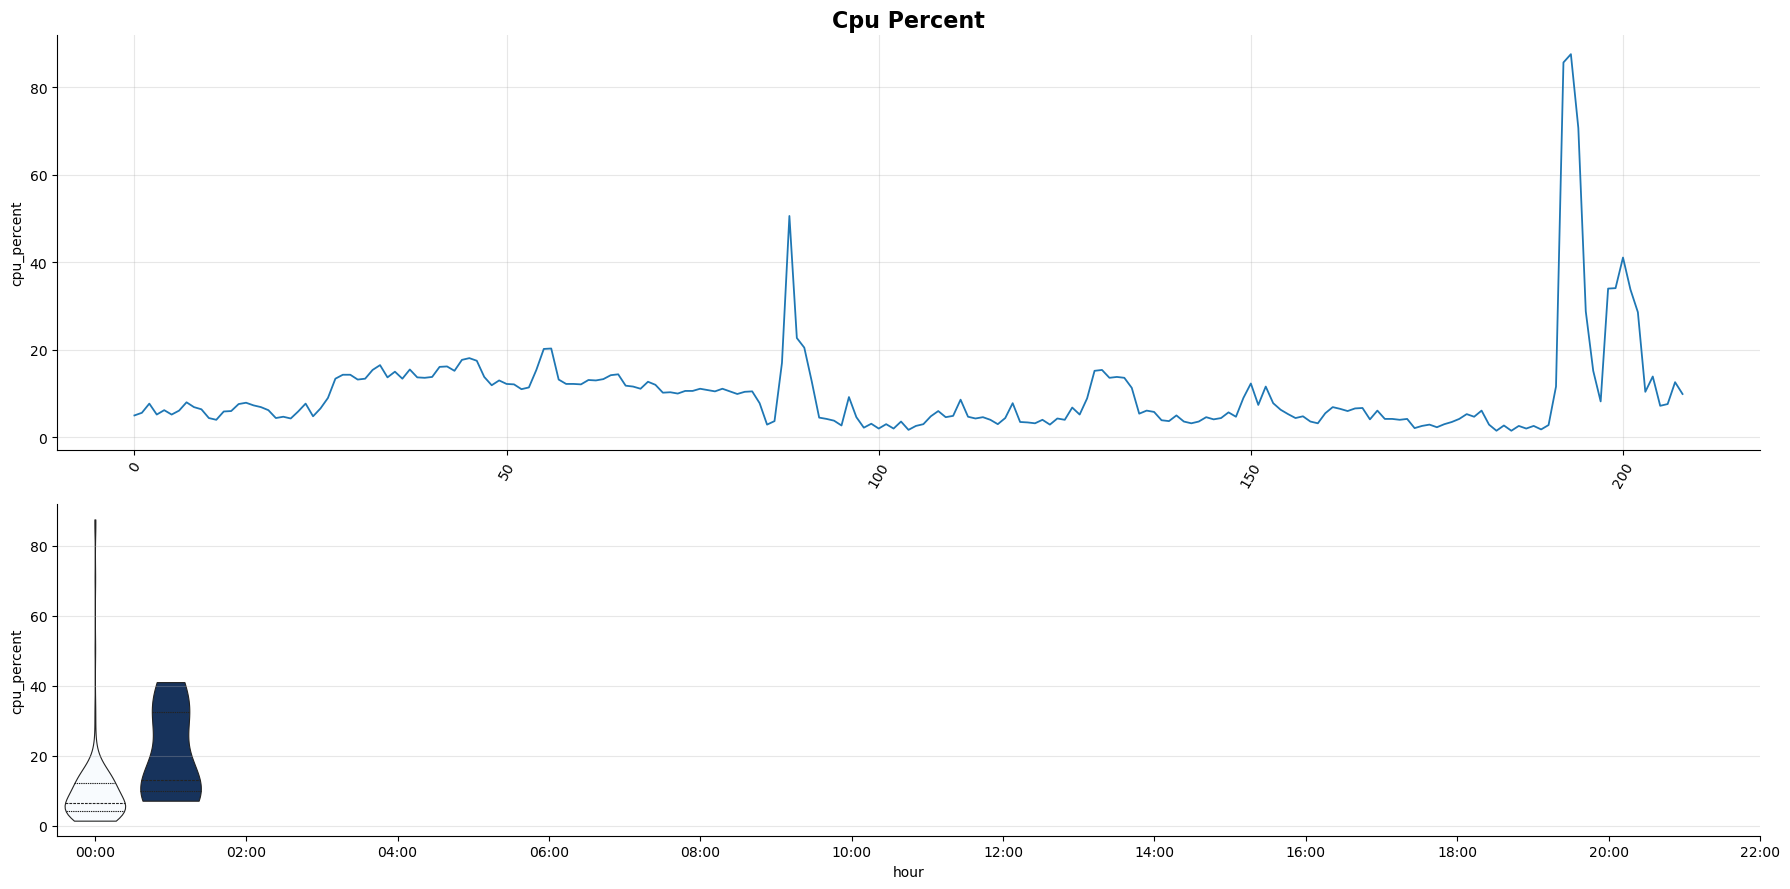

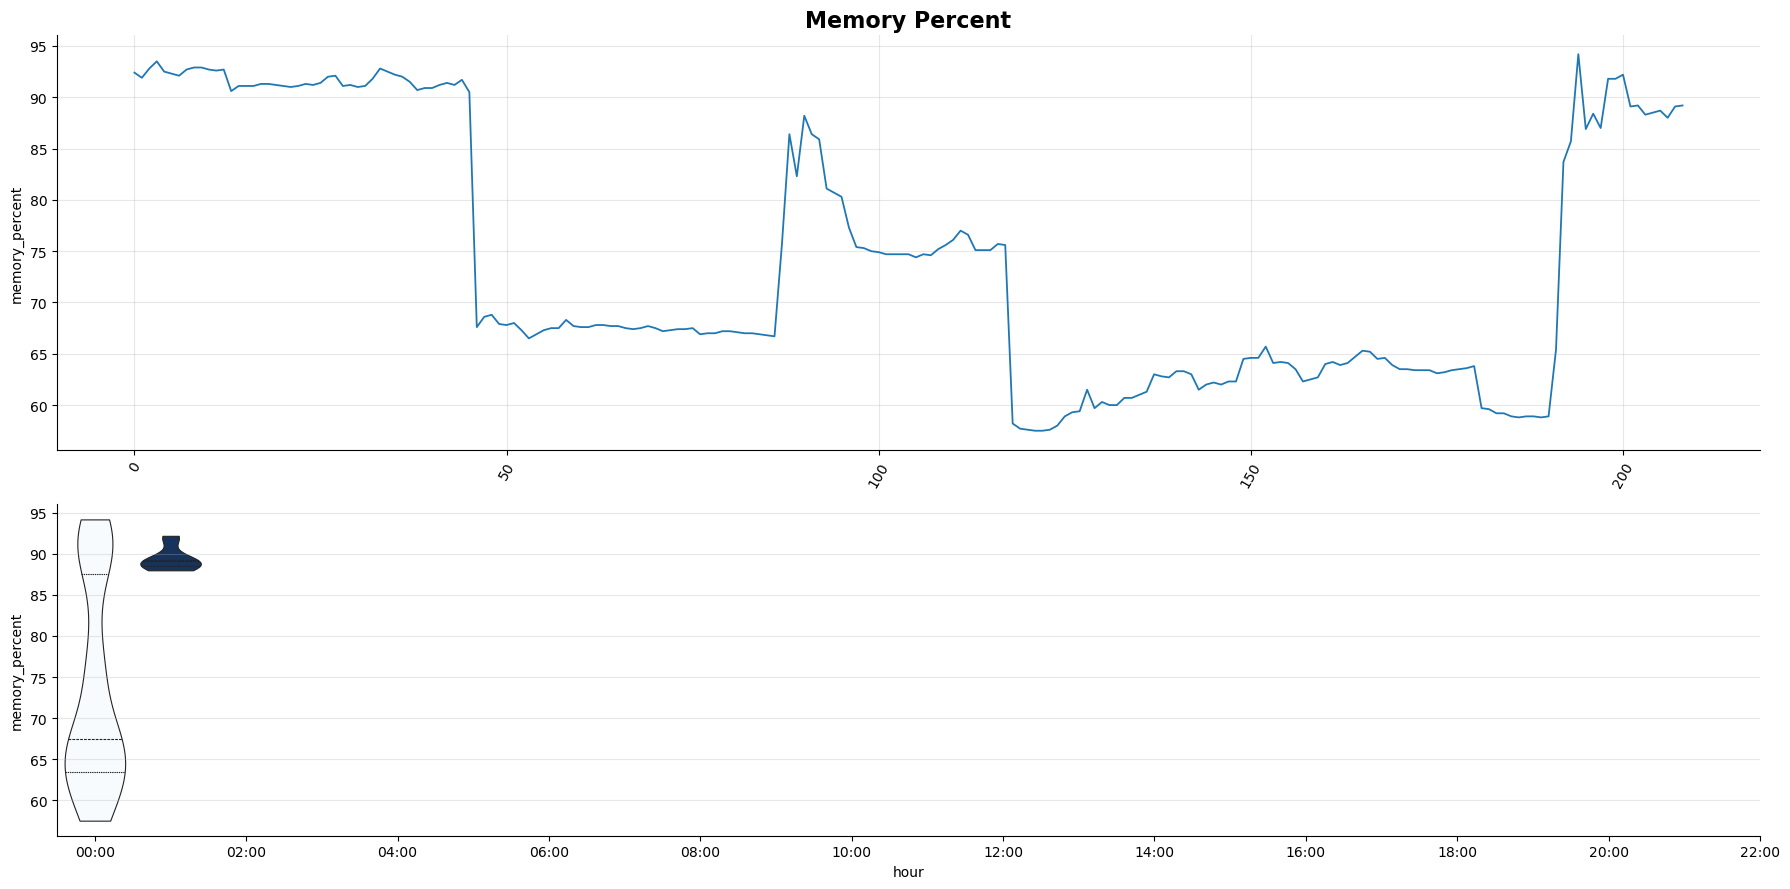

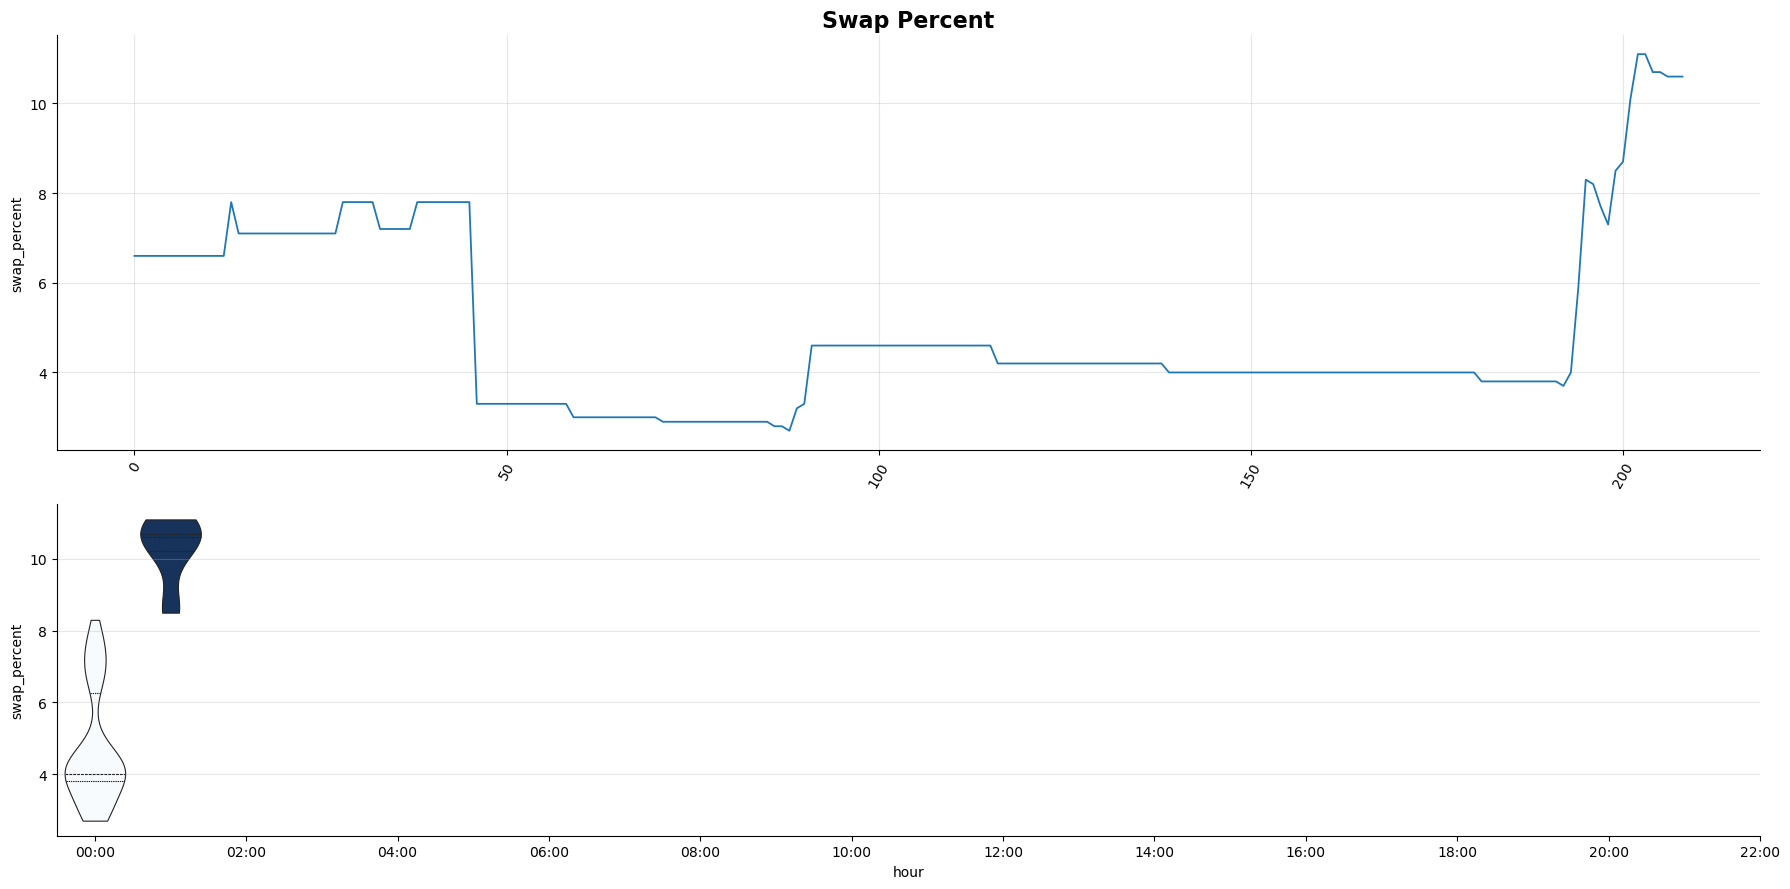

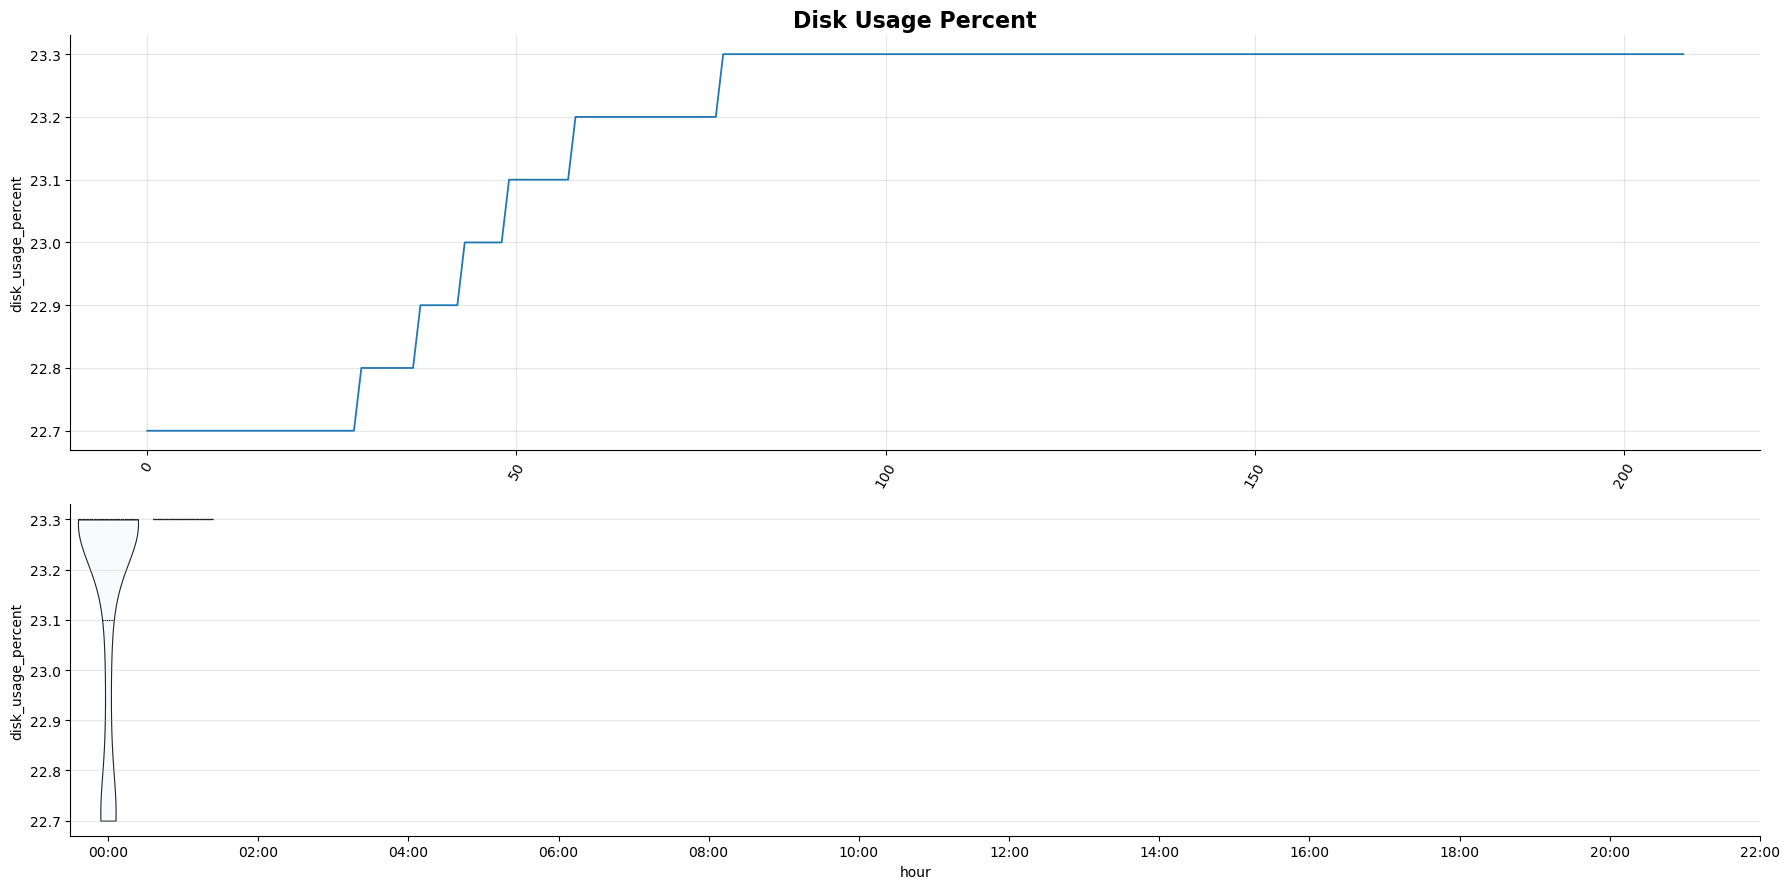

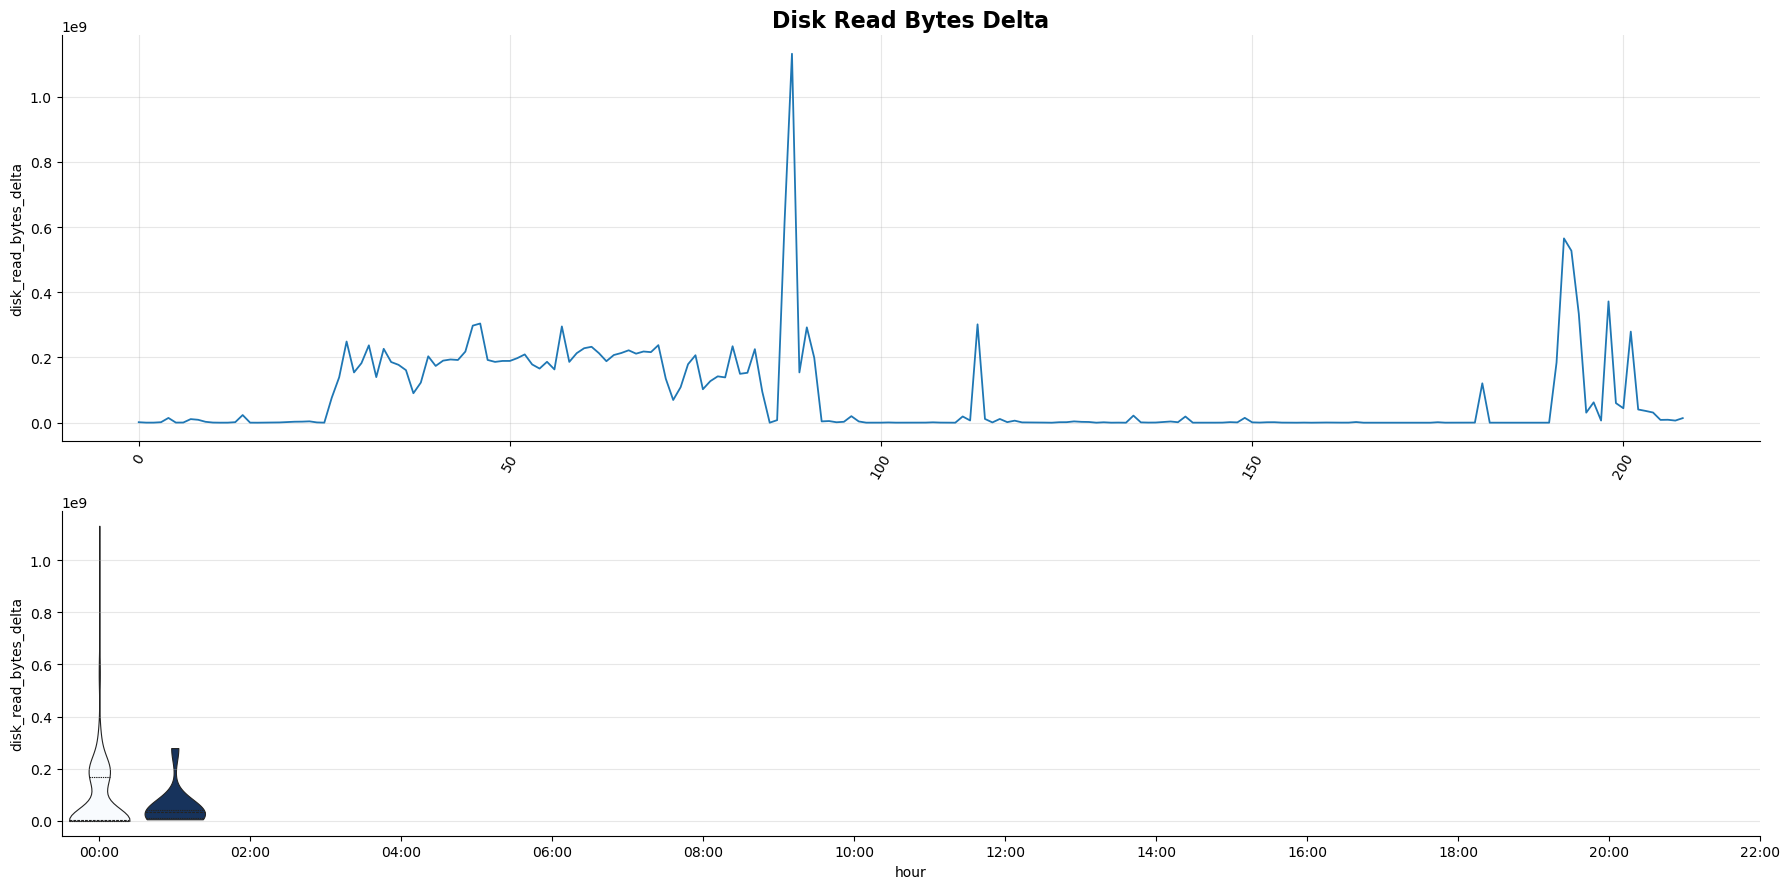

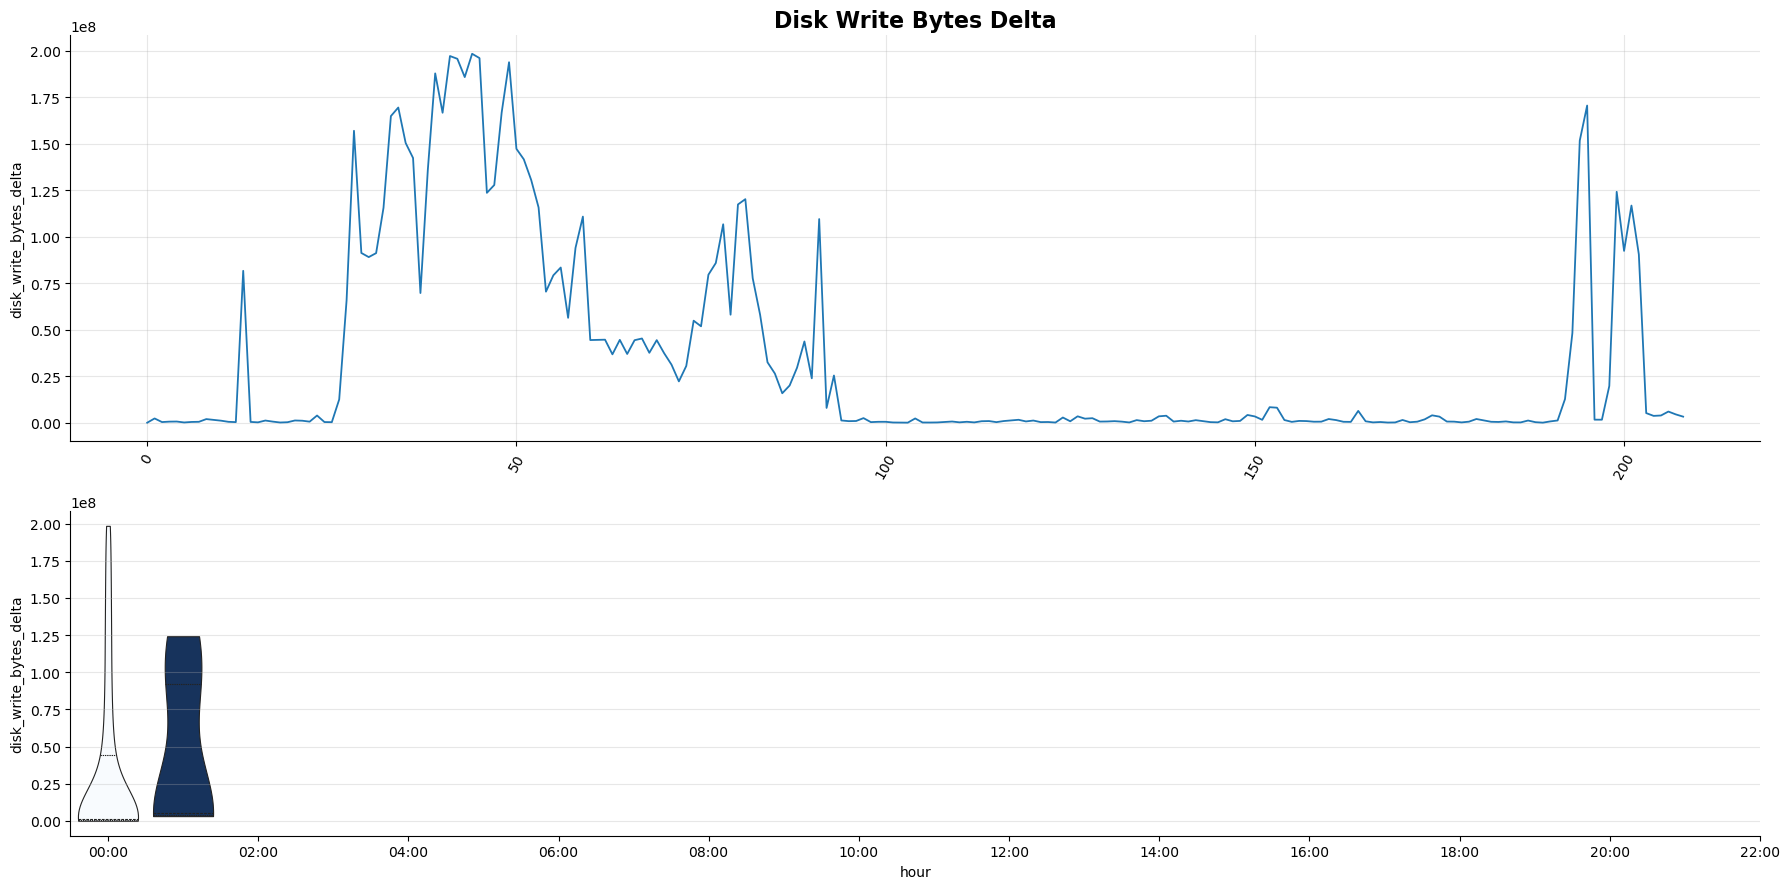

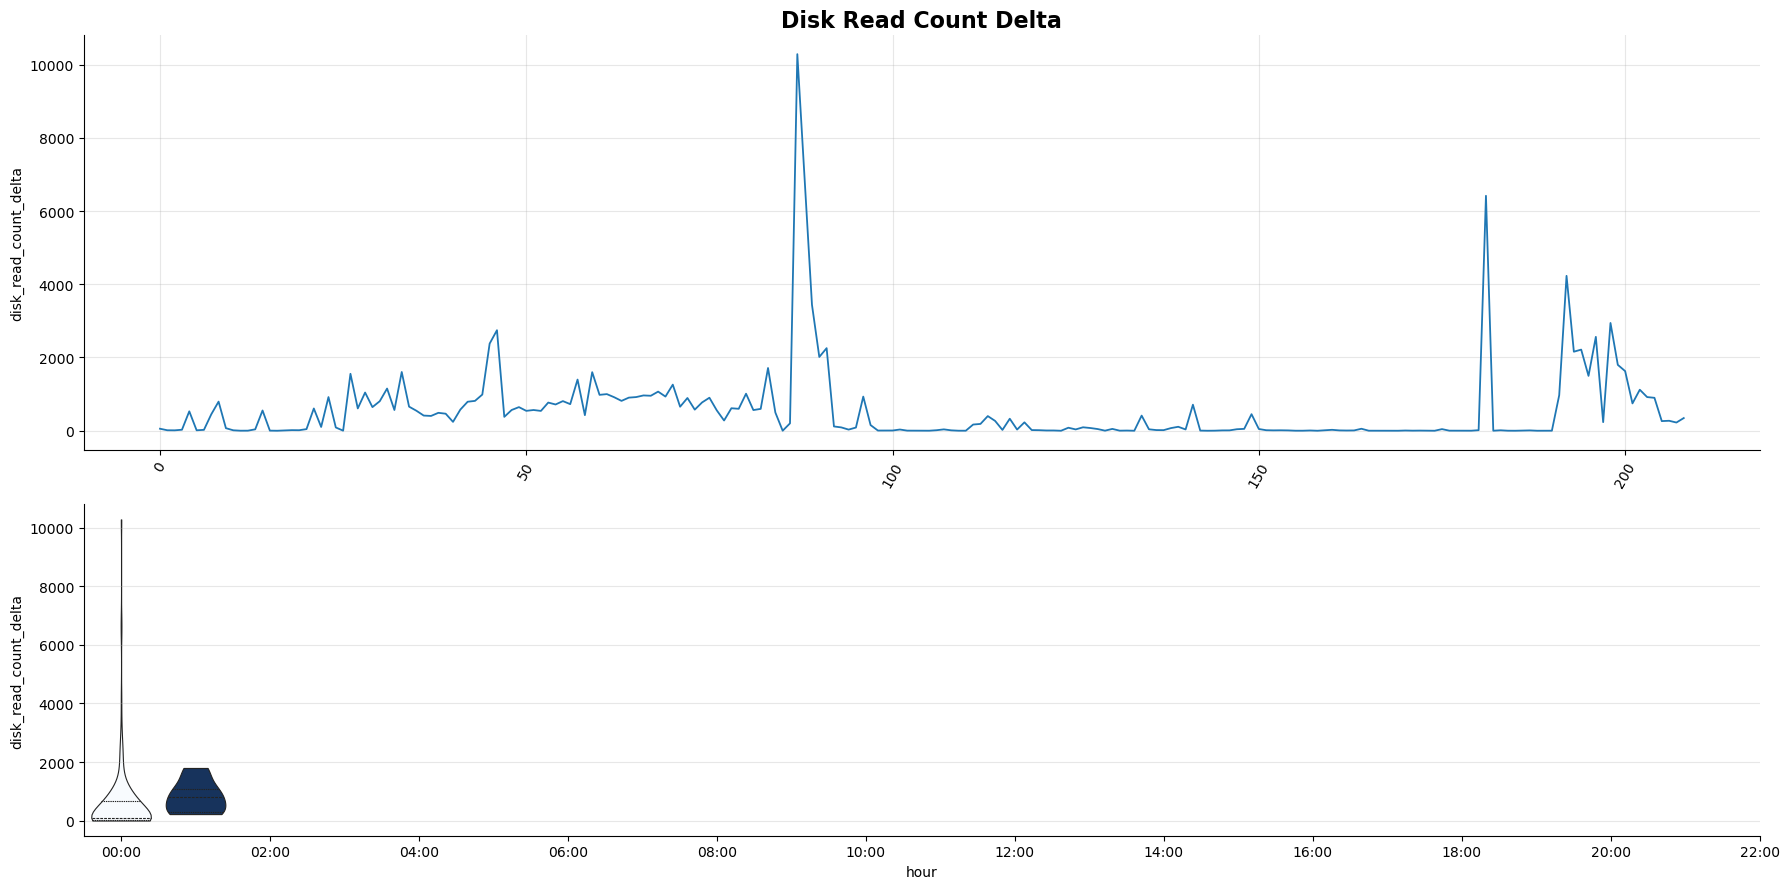

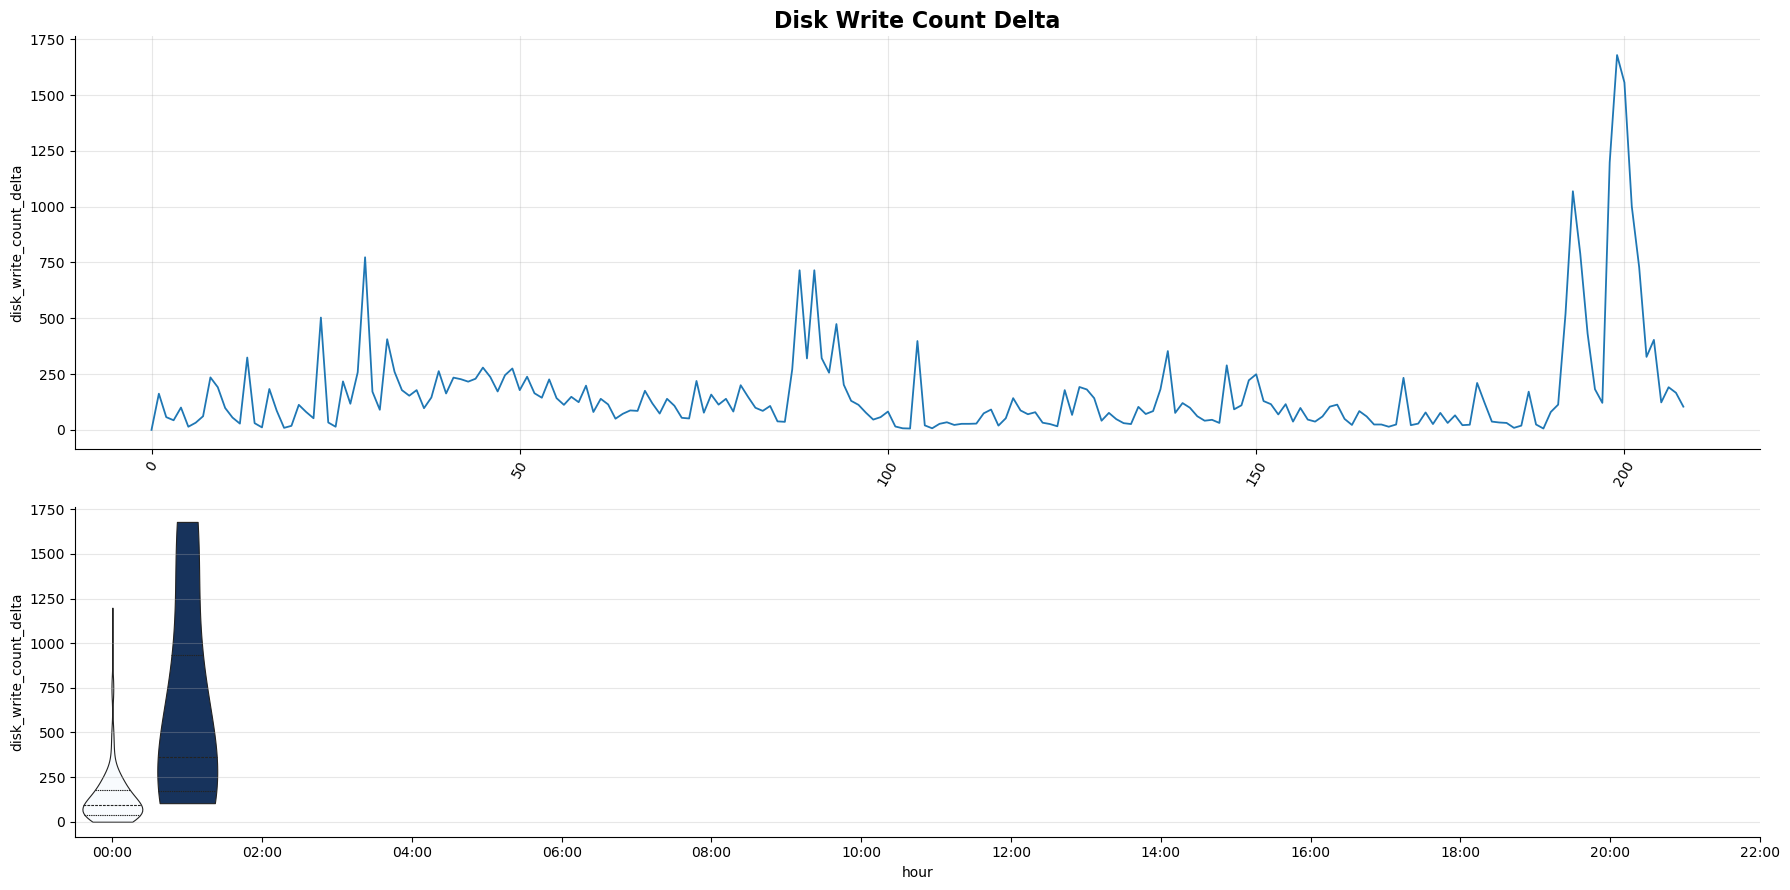

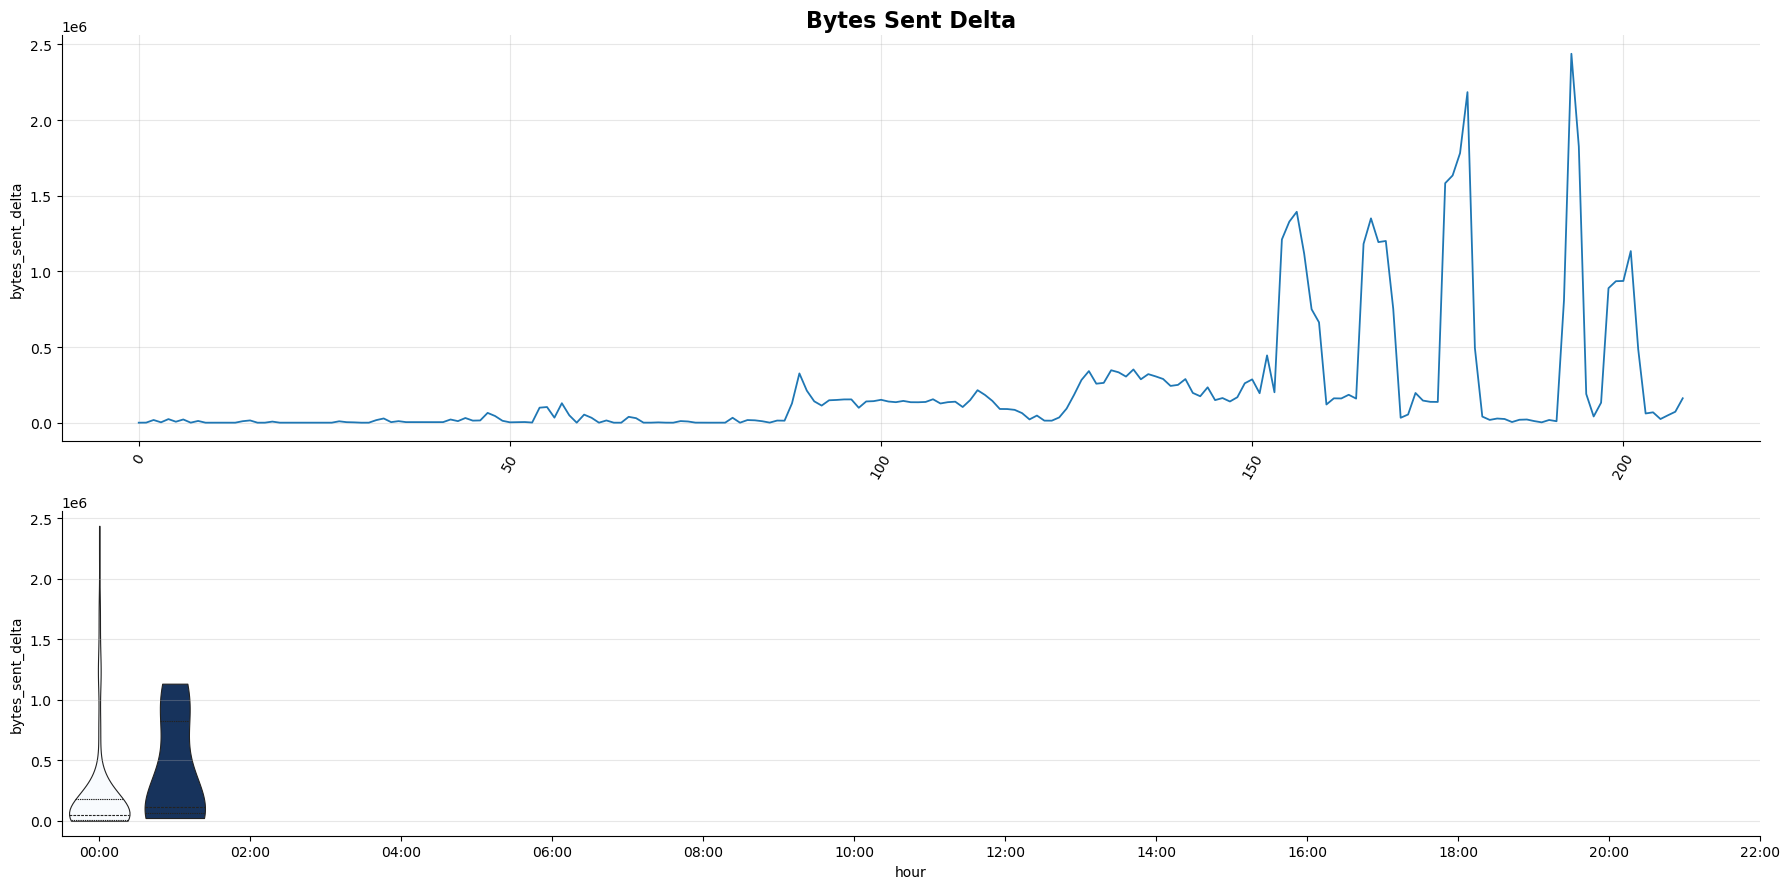

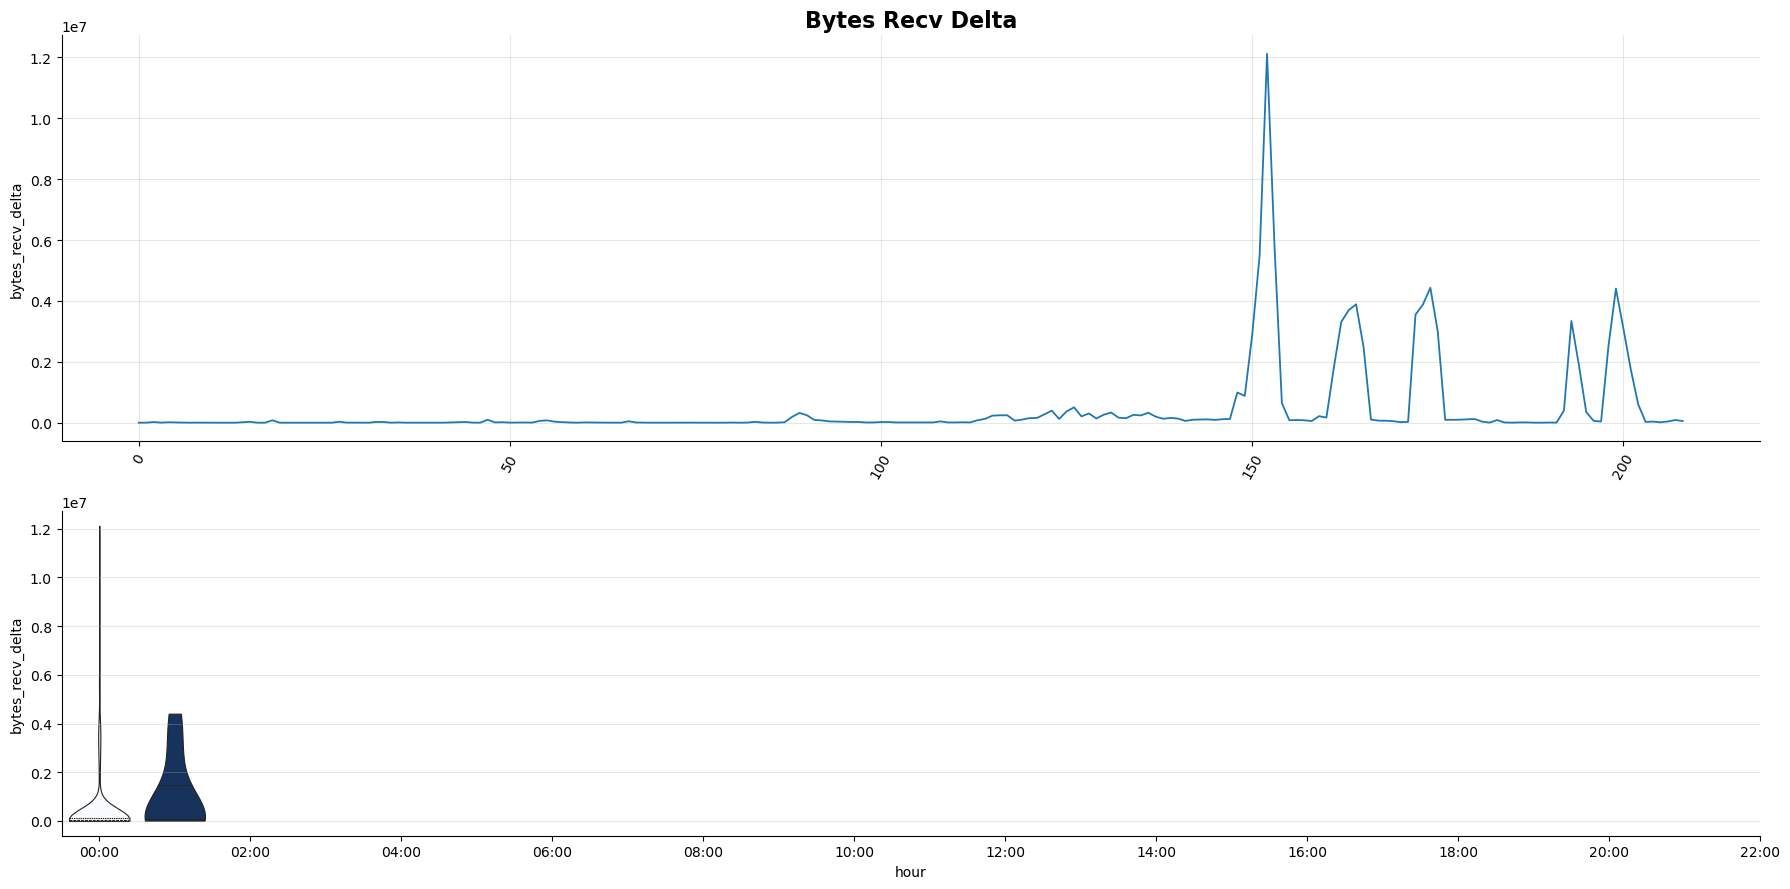

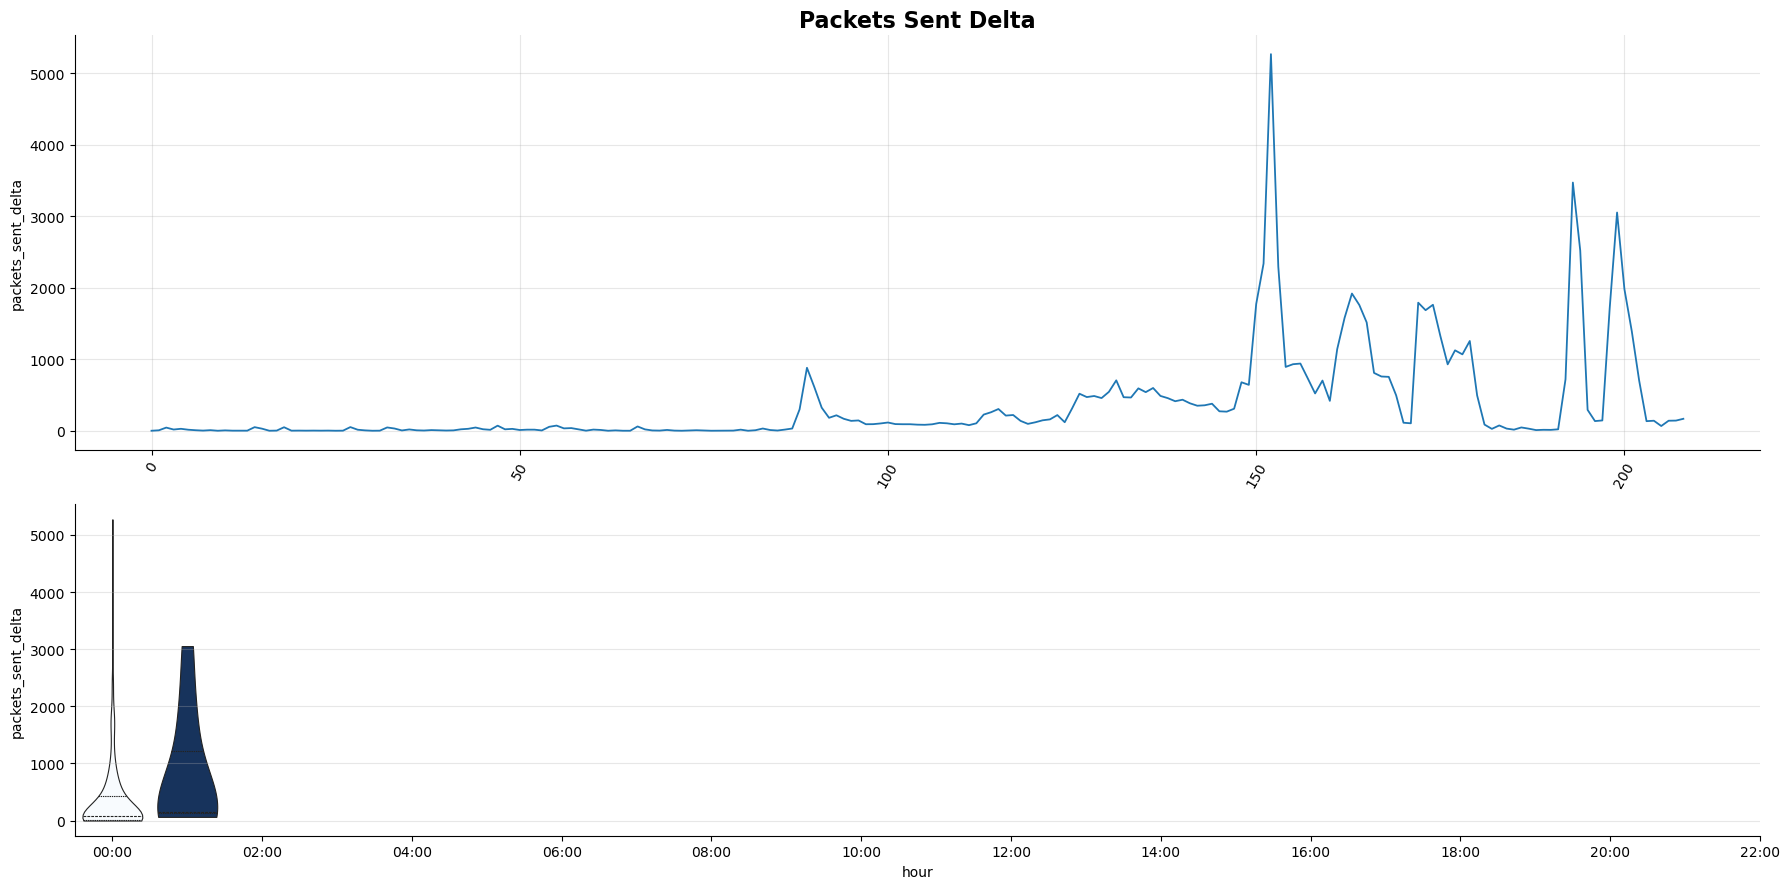

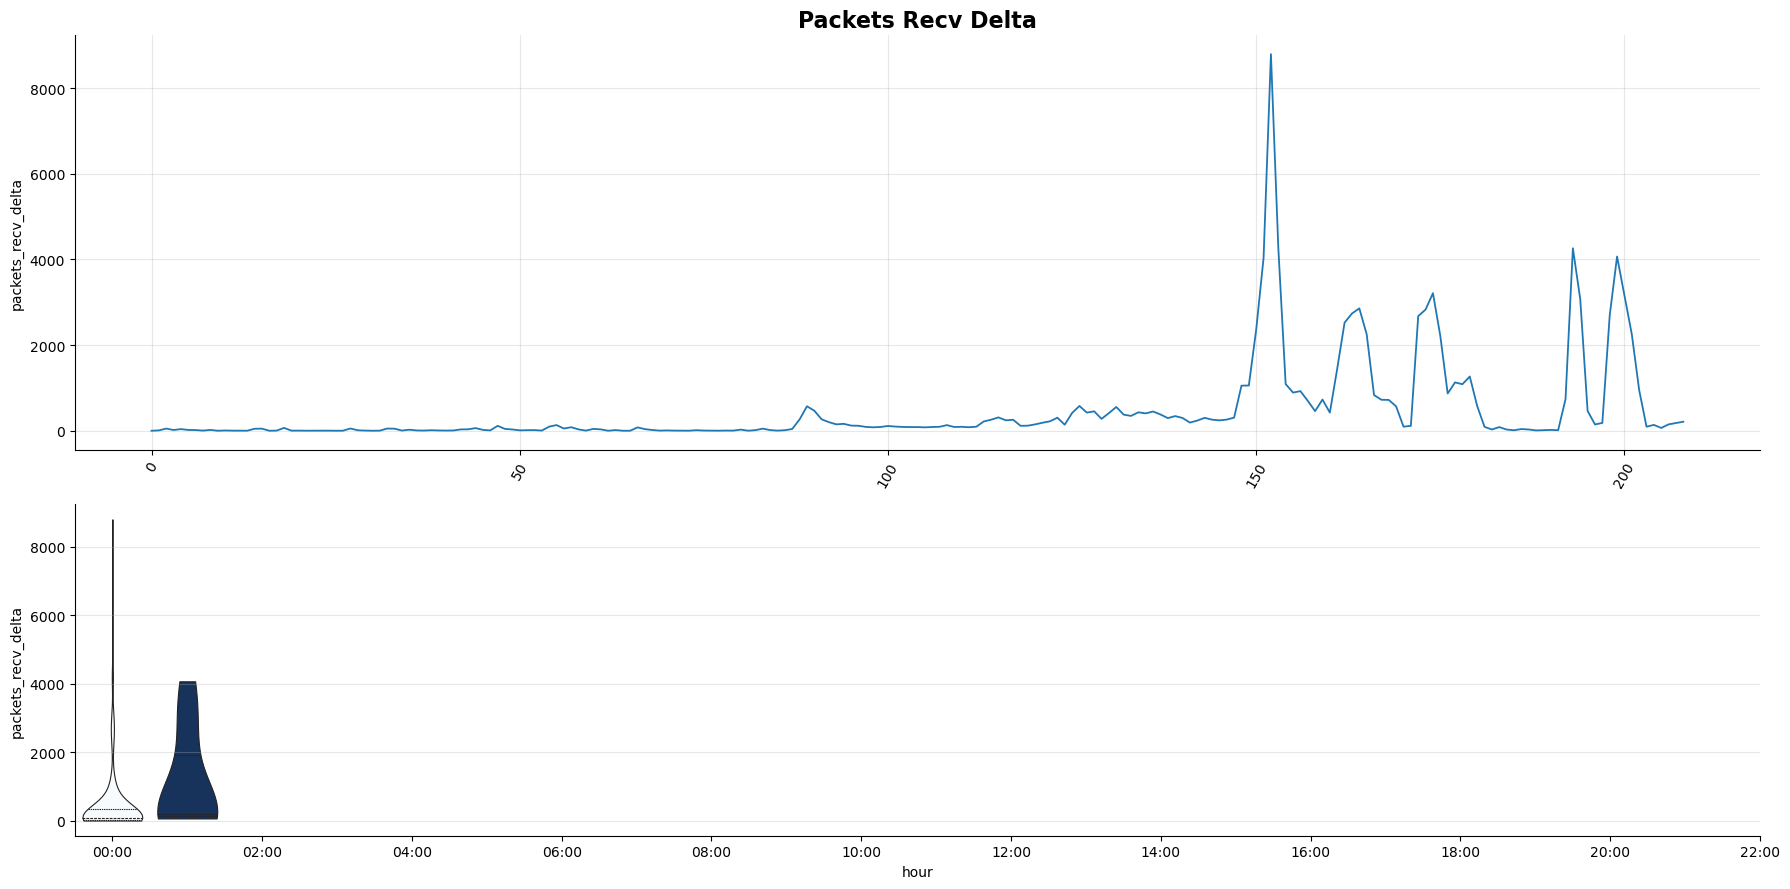

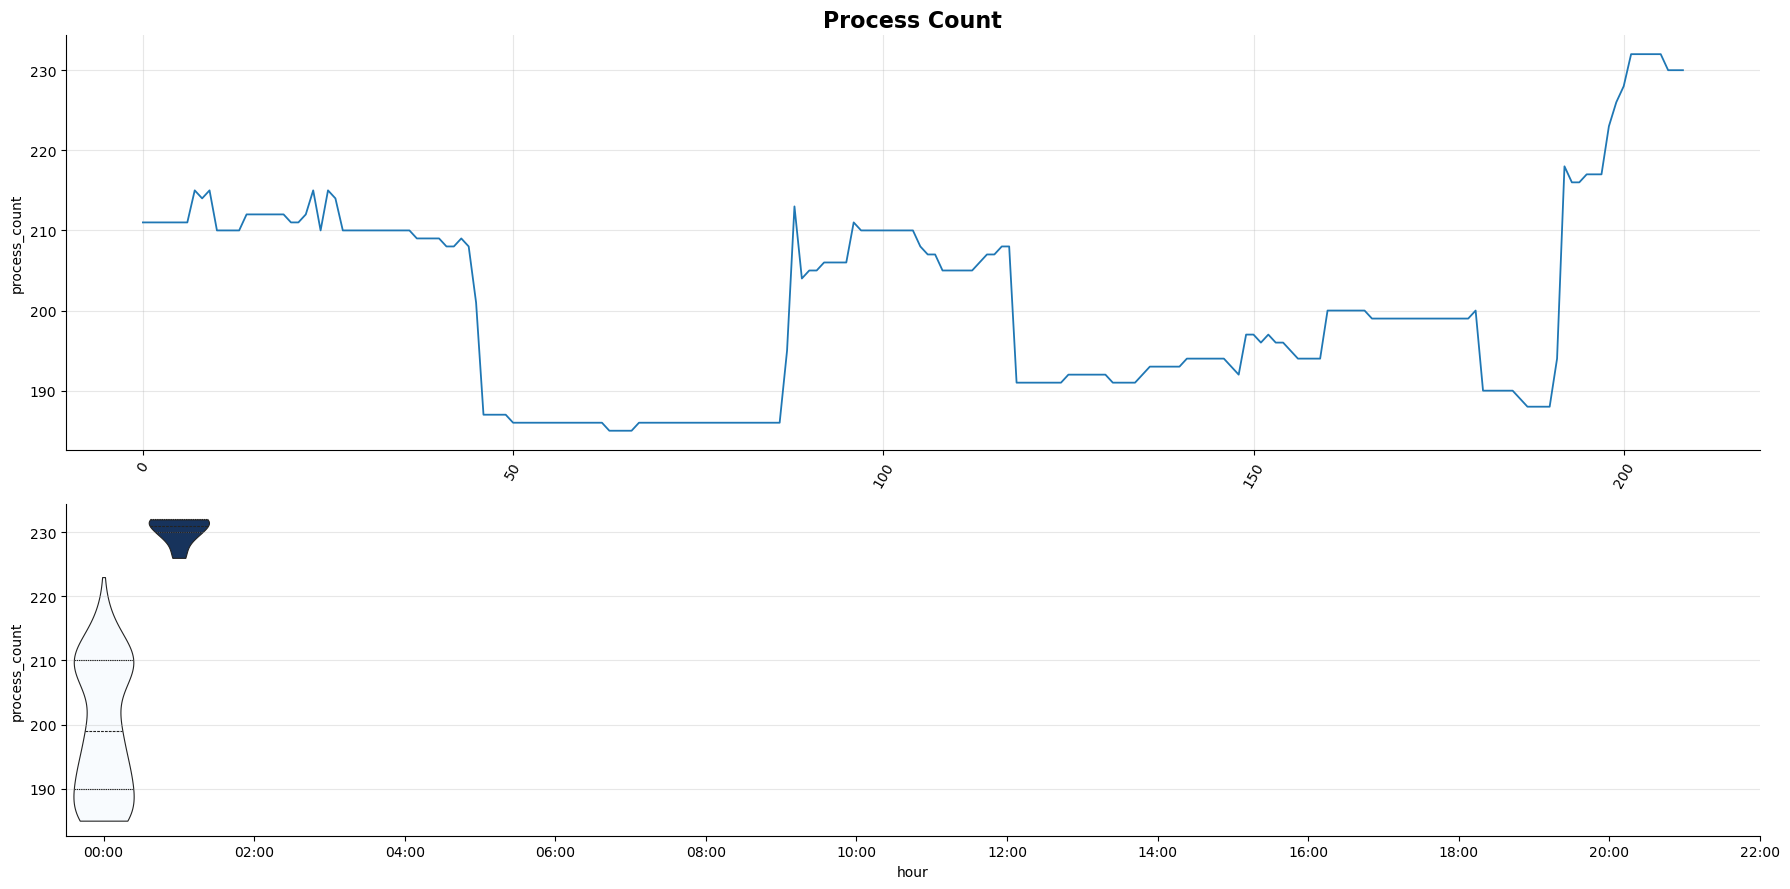

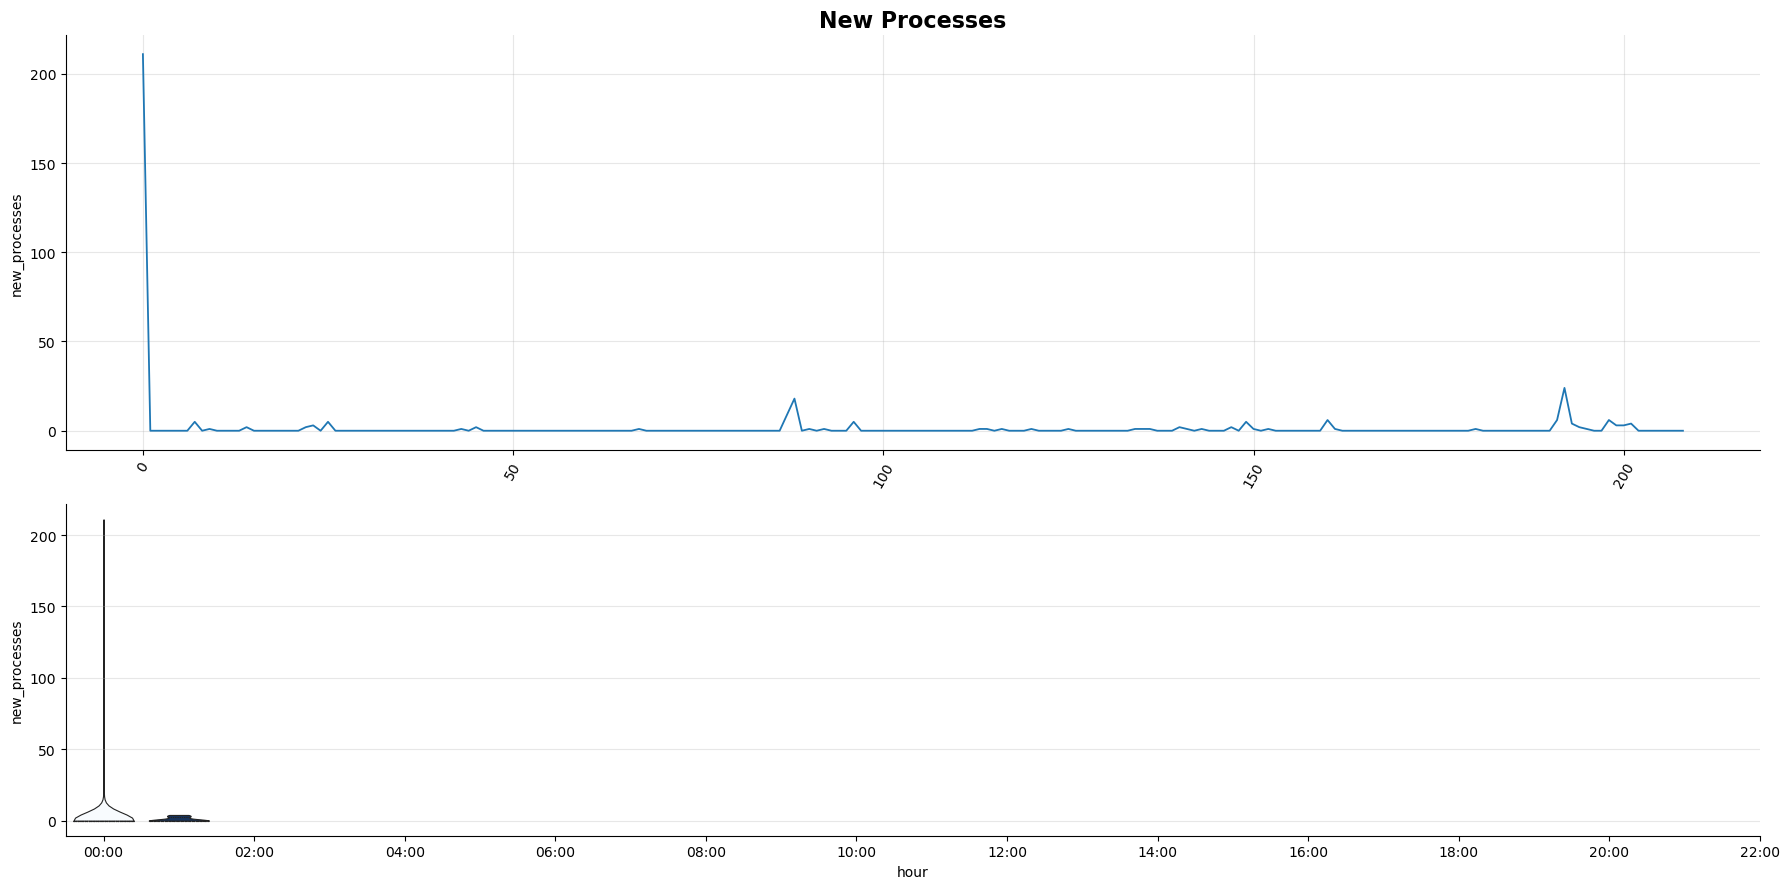

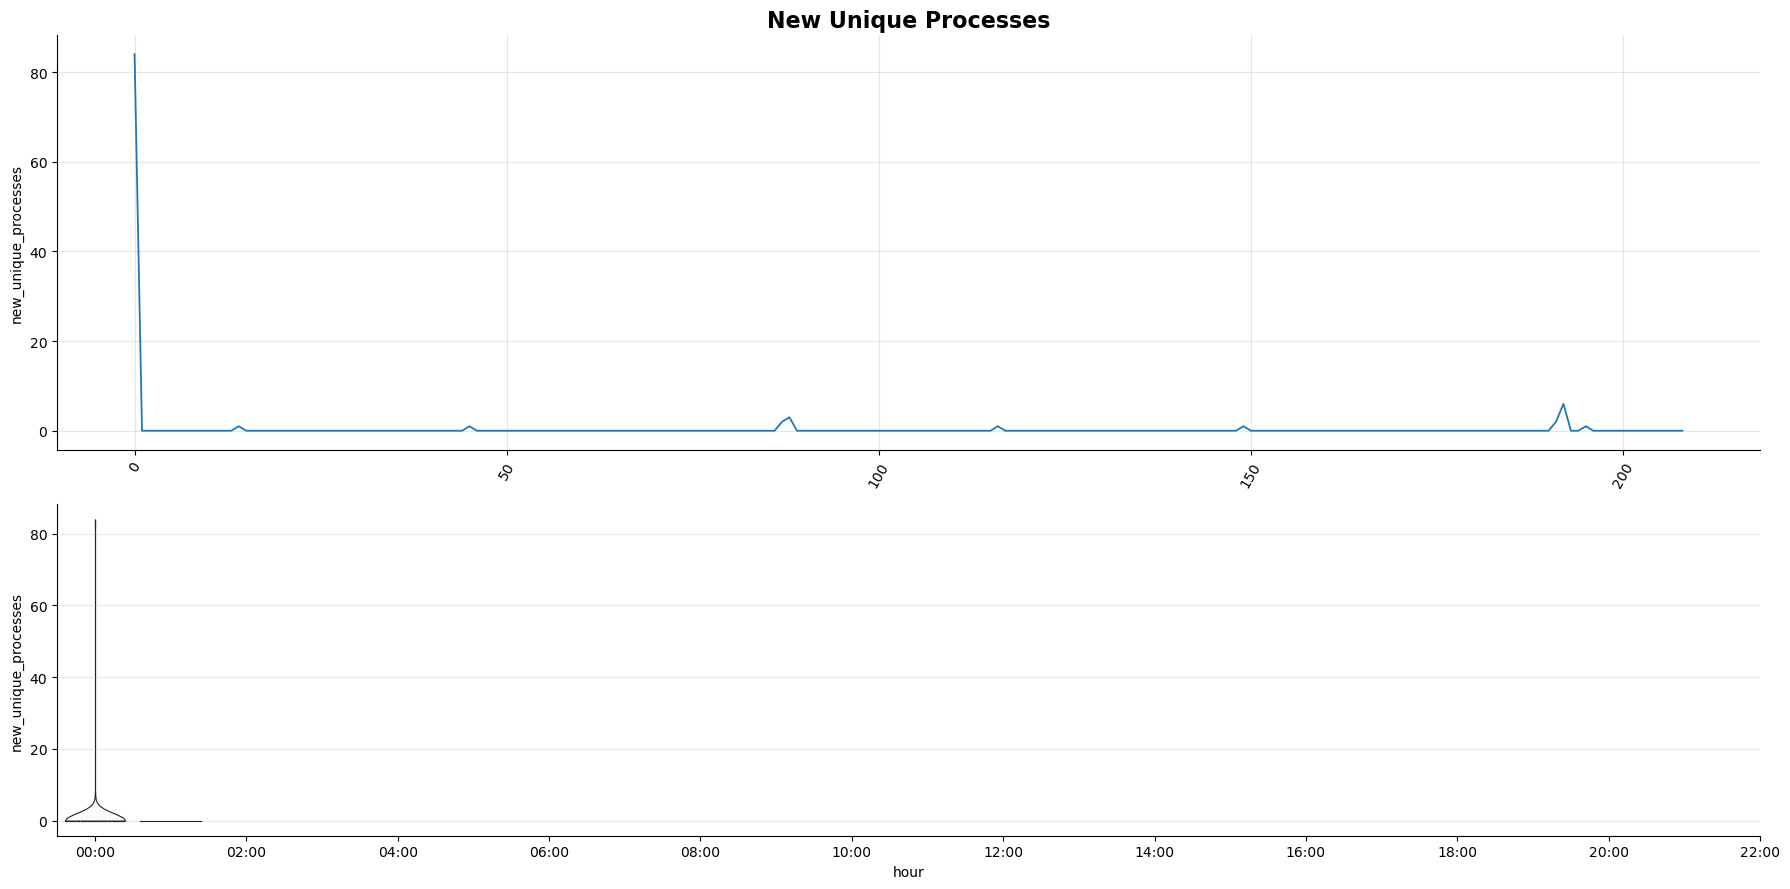

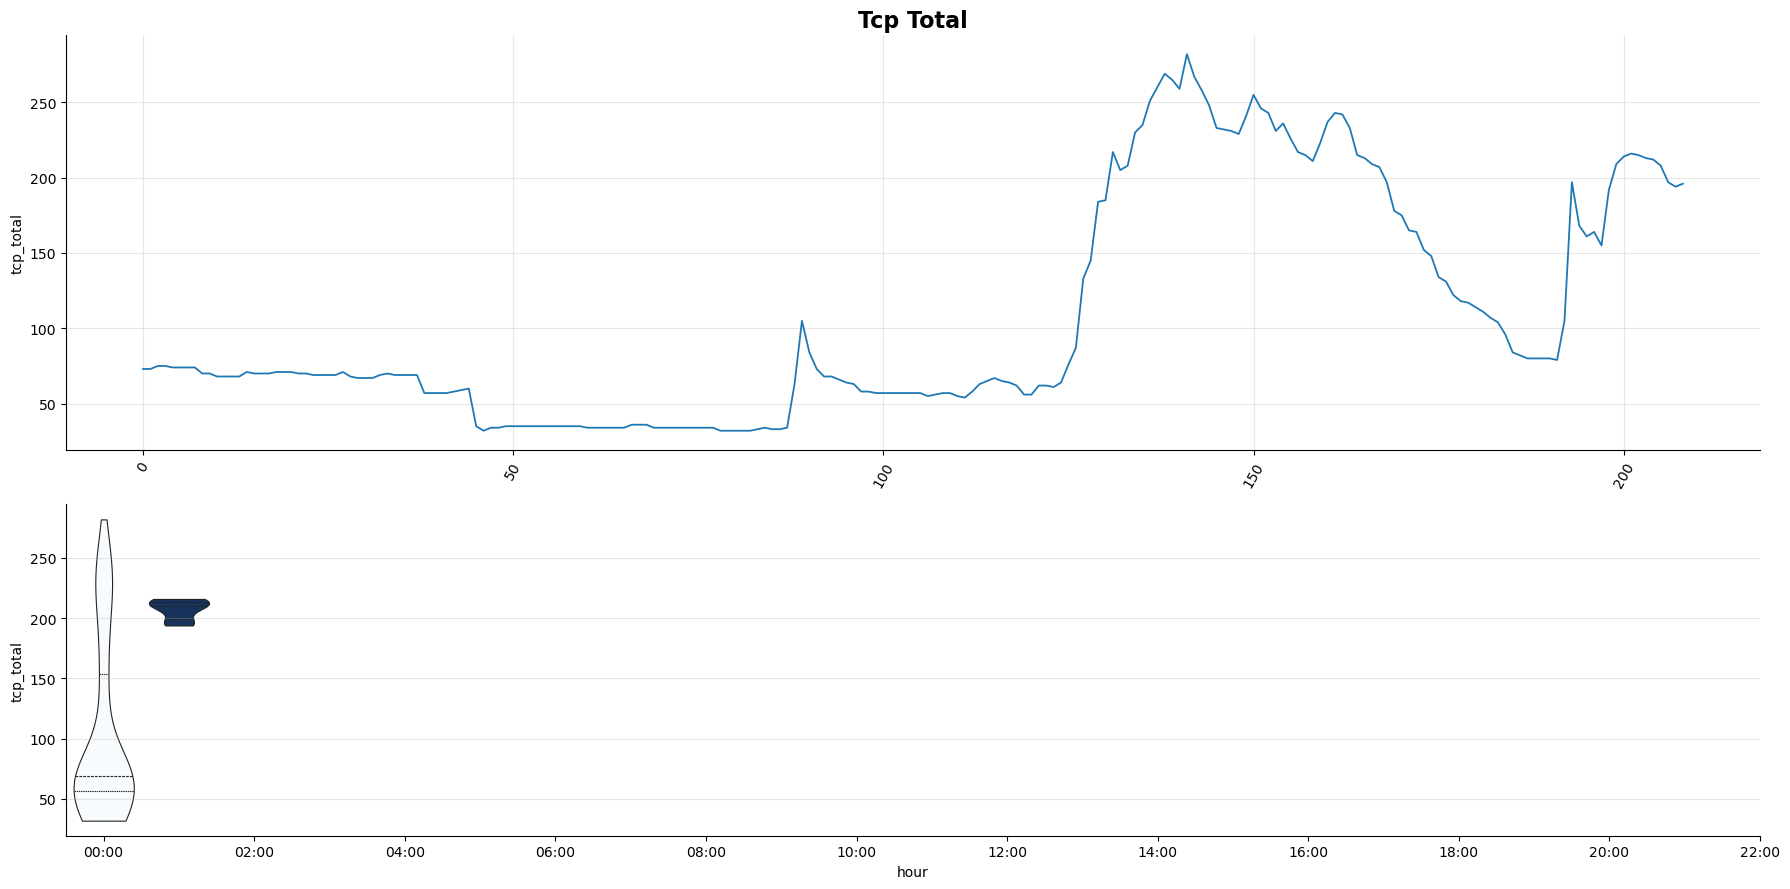

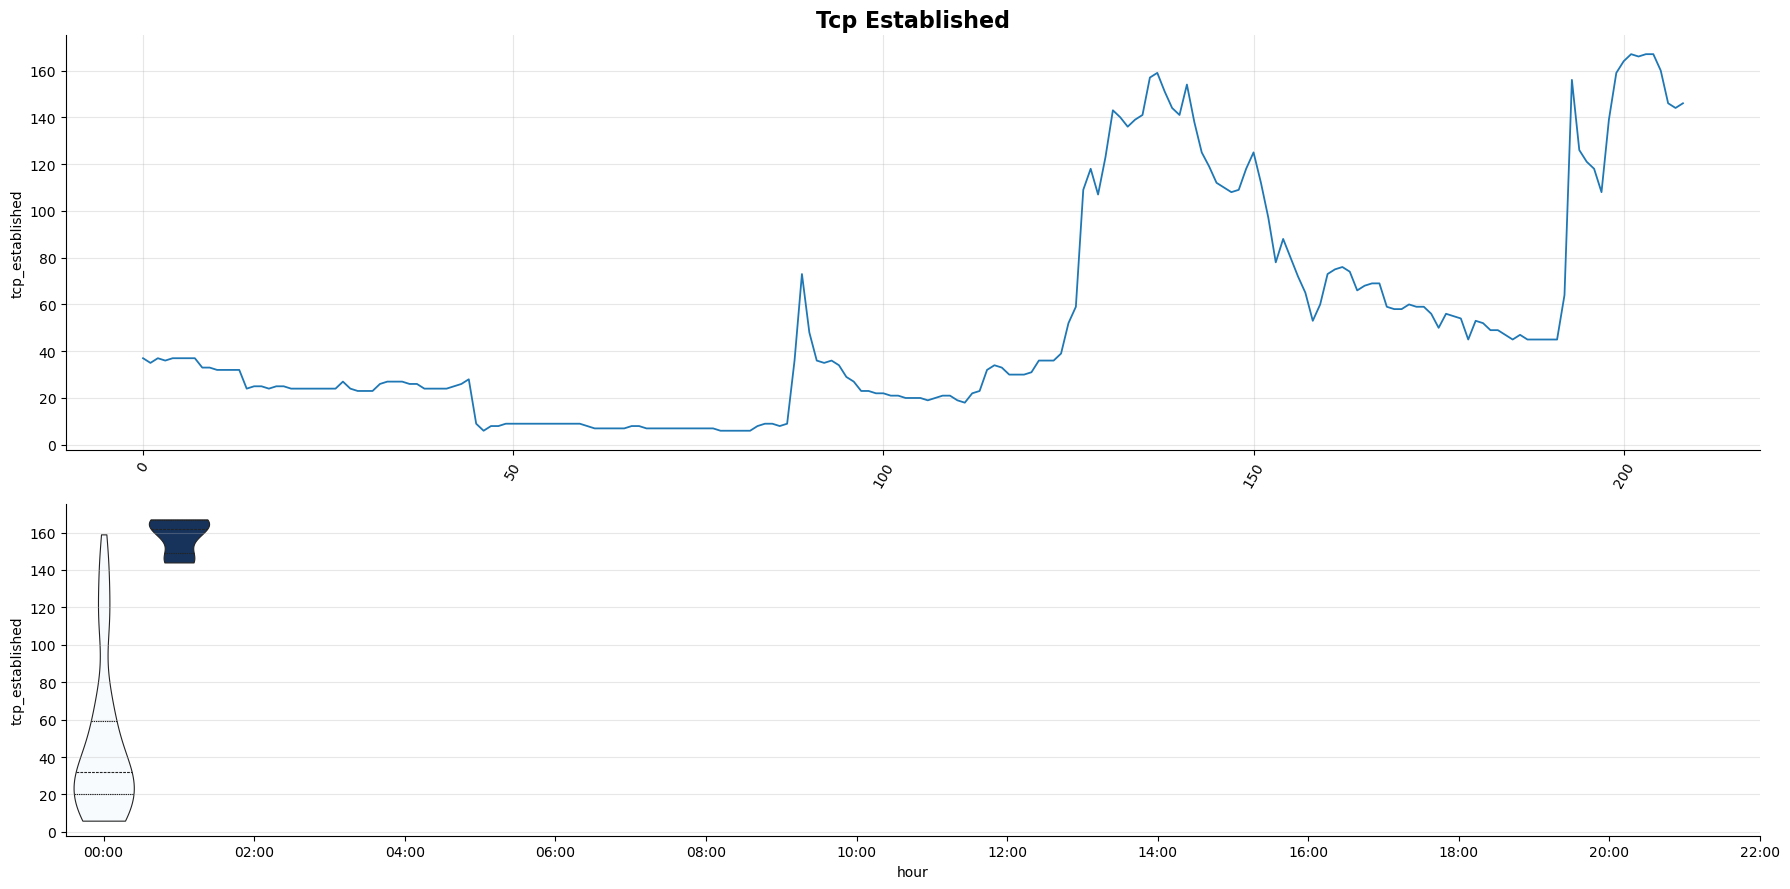

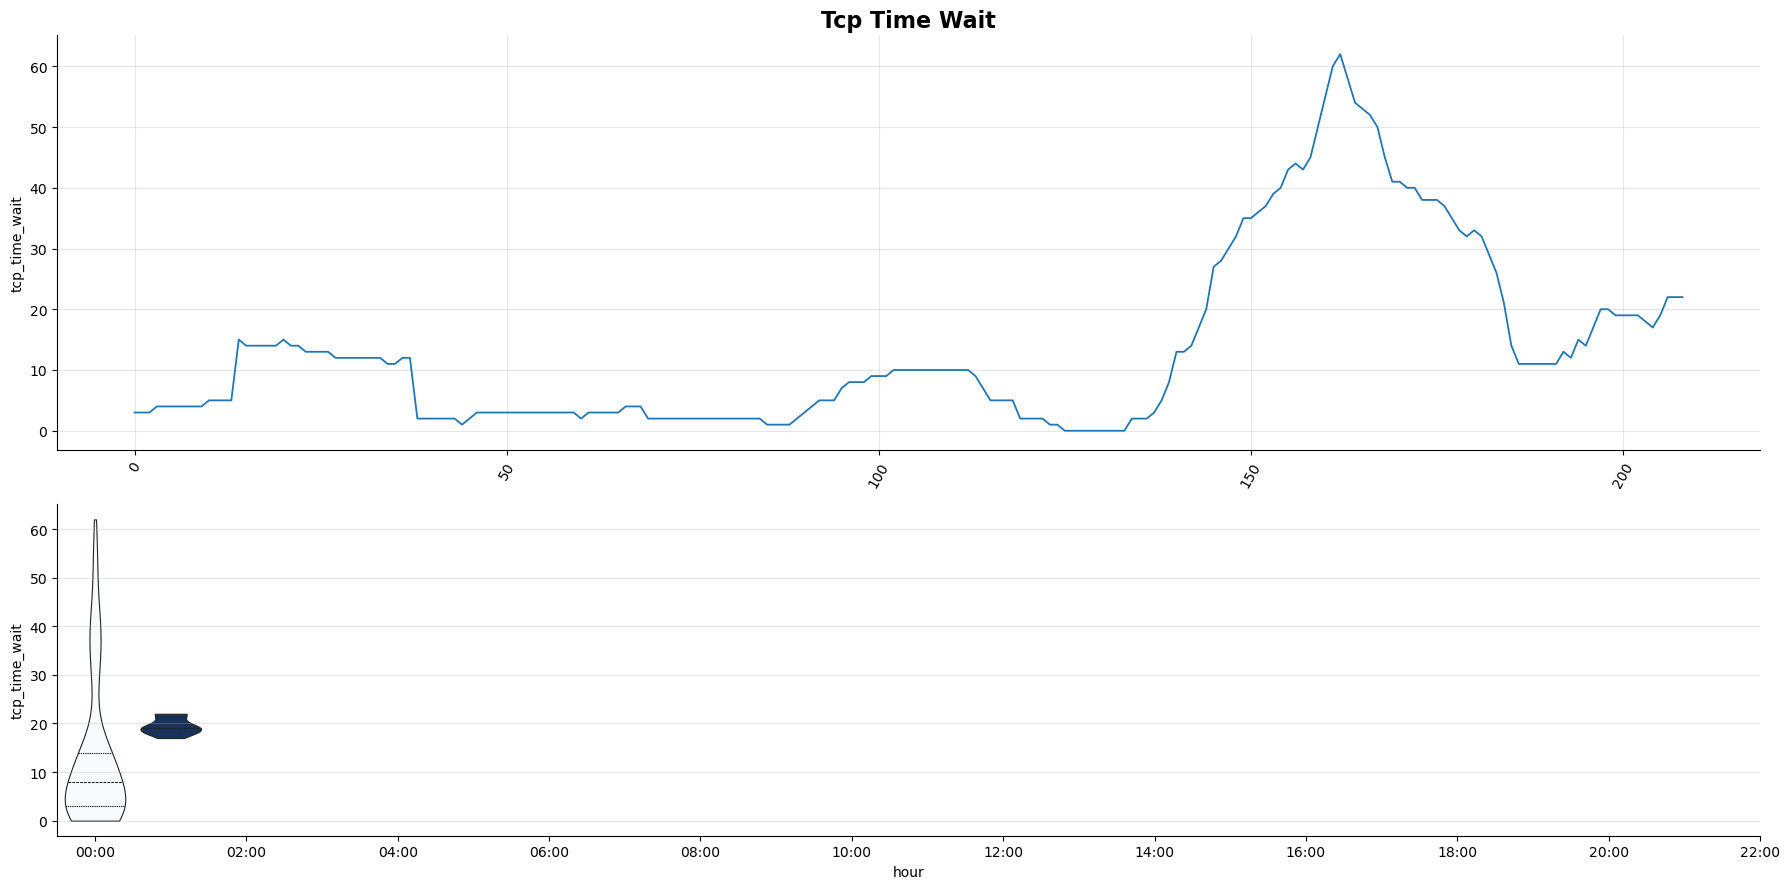

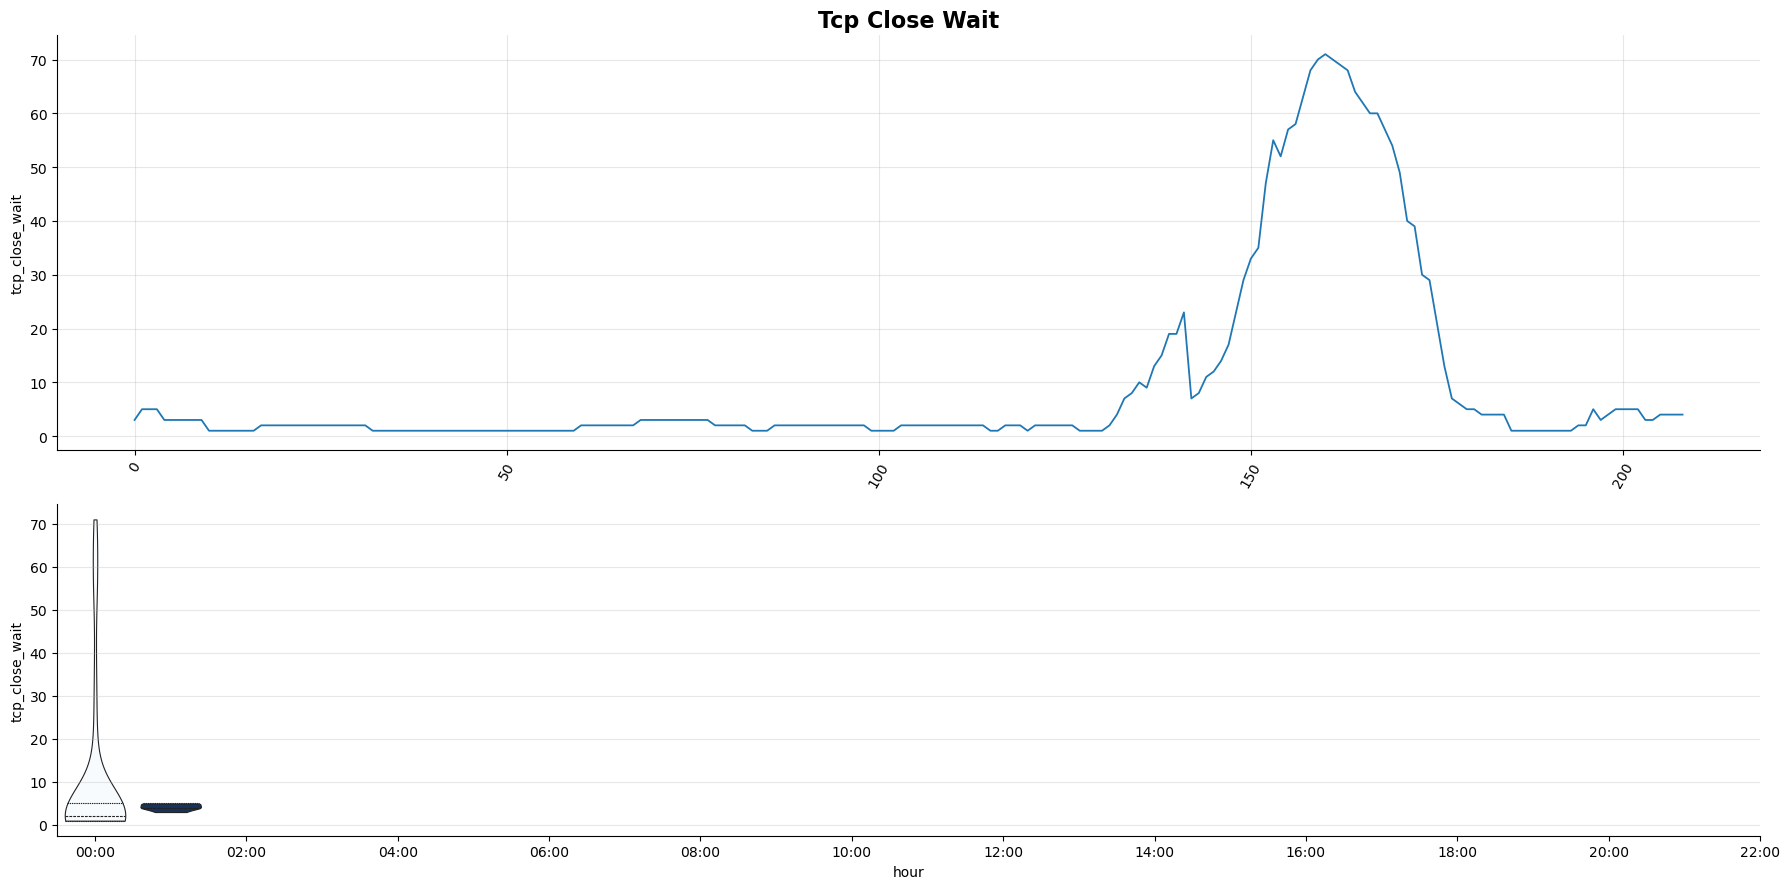

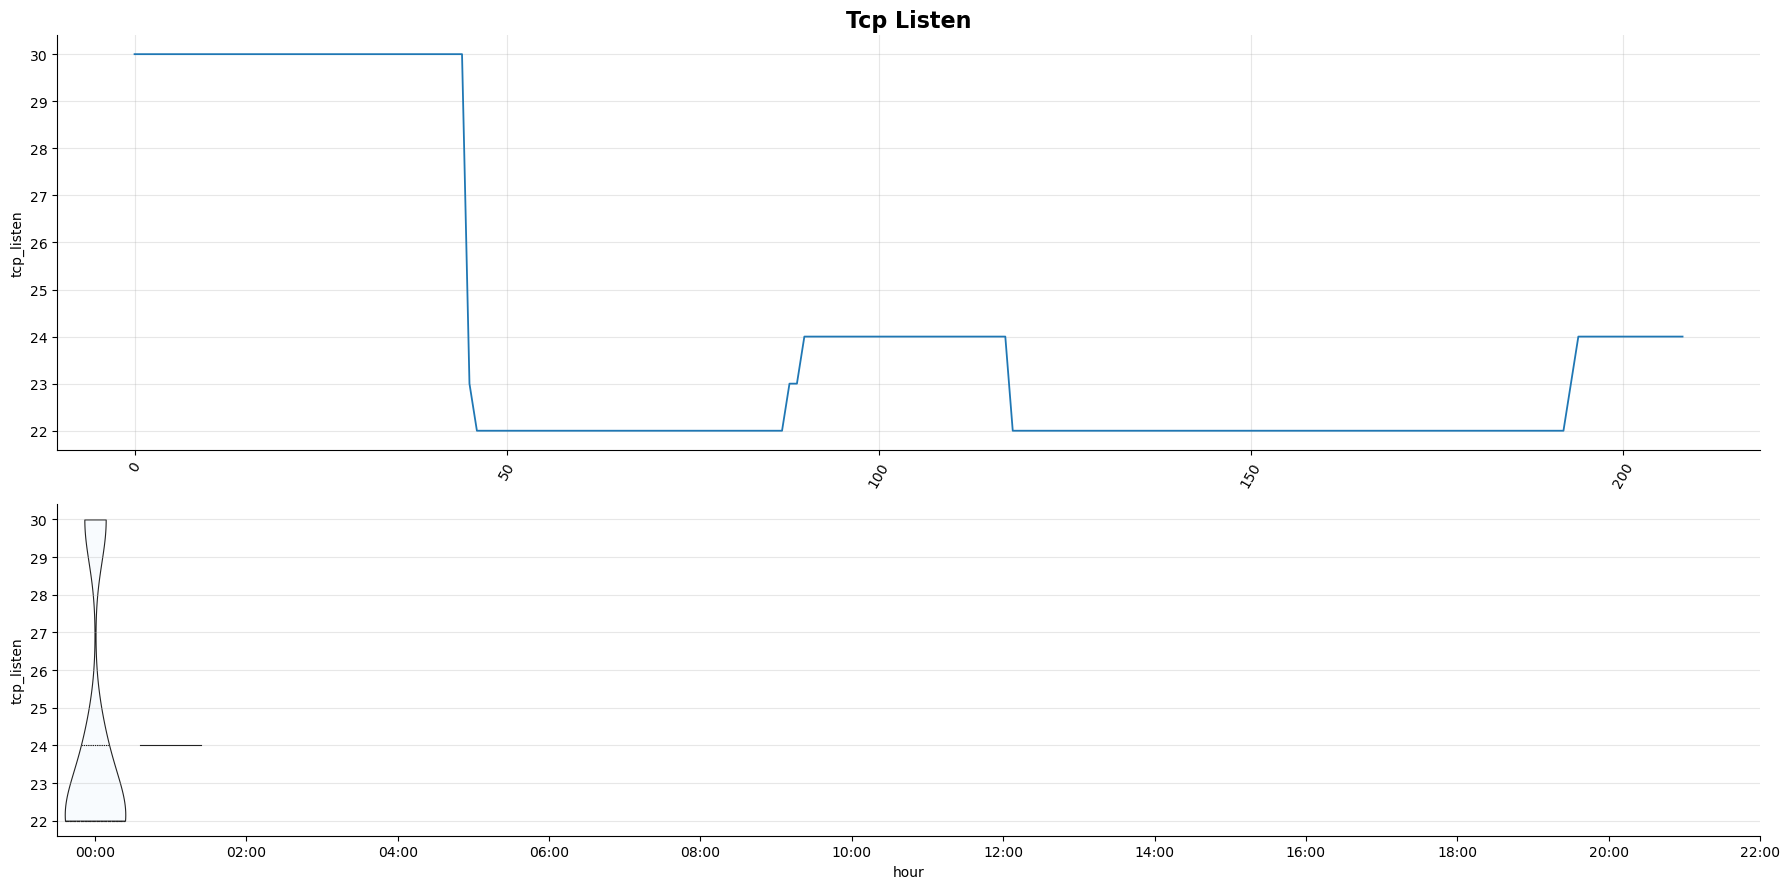

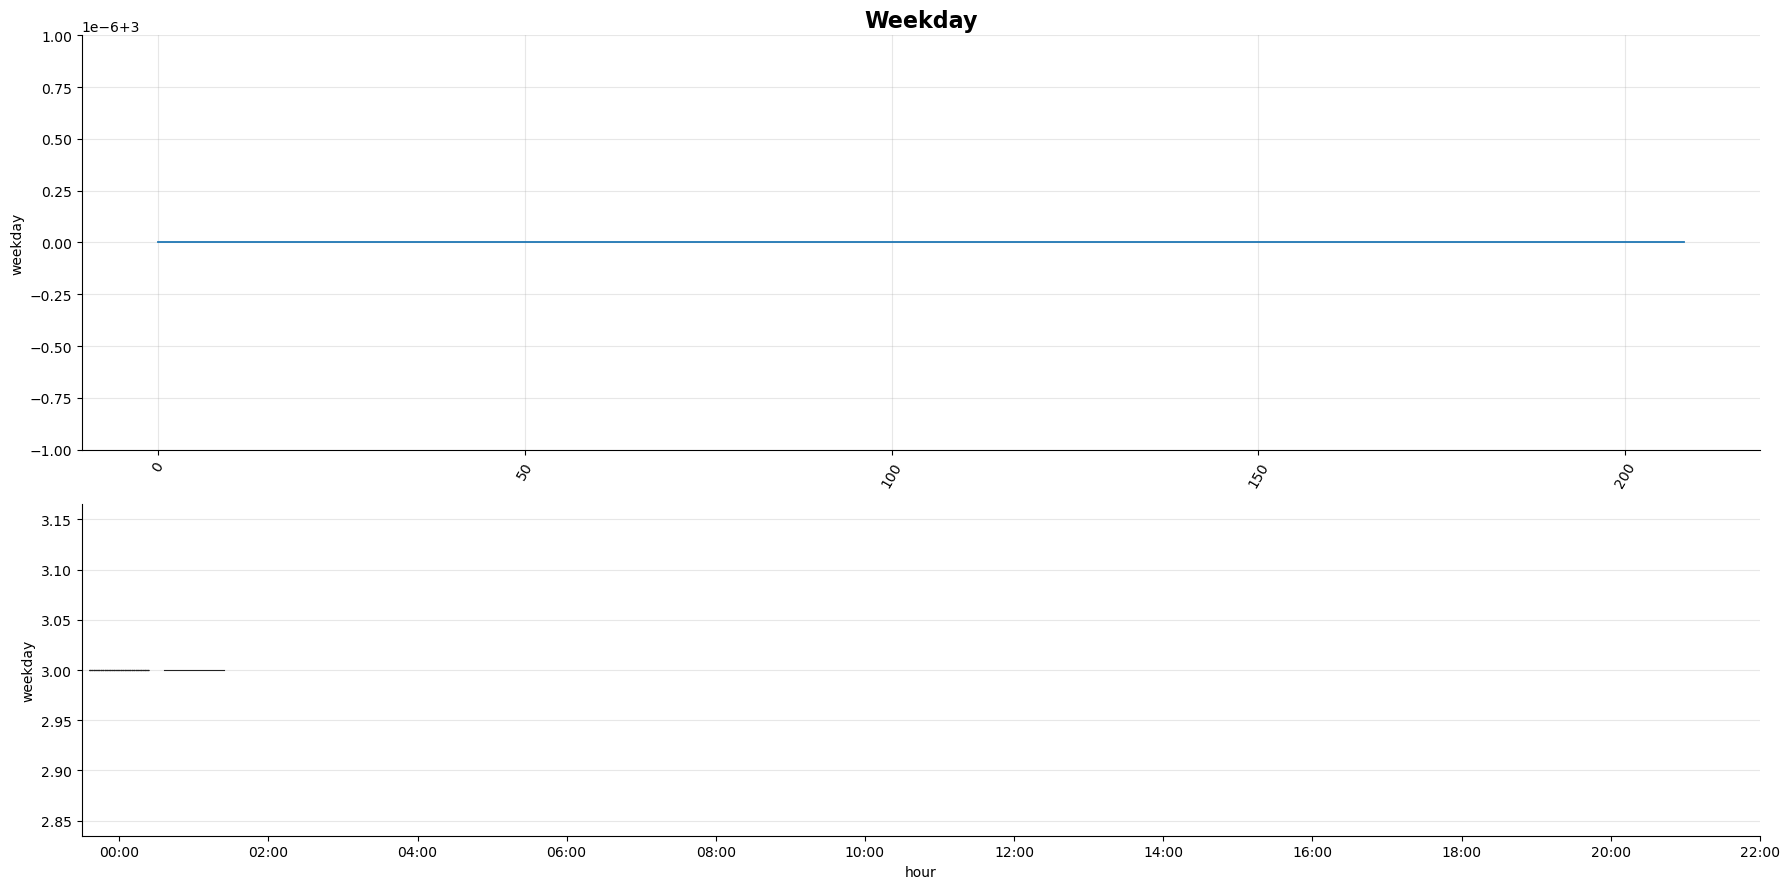

In [5]:
plot_time_series_and_violin(anomaly)

# Построение модели

Поскольку имеются только данные нормального функционирования системы, задача обнаружения аномалий рассматривается как задача обучения без учителя.

Автоэнкодер обучается восстанавливать признаки нормальных объектов, минимизируя ошибку реконструкции. Предполагается, что ранее не встречавшиеся аномальные состояния не будут эффективно реконструироваться моделью, вследствие чего ошибка восстановления окажется существенно выше

## Разбиение

In [6]:
sys.path.append(os.path.dirname(os.getcwd()))
from preprocess.classes.pipe_preprocess import PreprocessingPipeline
from classes.ueba_datasets import UEBADataset

In [7]:
file_path = Path.cwd().parent / 'data' / 'dataset.csv'

normal = pd.read_csv(file_path)

Посколько данные представляют собой временной ряд с интервалом замера в 5 сек, то разбиение выполняется без перемешивания.

Ксли использовать случайное разбиение, то в модель попадали бы будующие моменты t,c , что исказило бы оценку кач-ва

In [8]:
train_size = int(len(normal) * 0.8)

train = normal.iloc[:train_size].copy()
val = normal.iloc[train_size:].copy()

In [9]:
pipeline = PreprocessingPipeline()

X_train = pipeline.fit_transform(train)
X_val = pipeline.transform(val)

X_anomaly = pipeline.transform(anomaly)

d:\App\Anaconda\envs\pytorch_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


In [10]:
print(X_train.shape)
print(X_val.shape)
print(X_anomaly.shape)

(13796, 27)
(3451, 27)
(209, 27)


In [11]:
train_dataset = UEBADataset(X_train)
val_dataset = UEBADataset(X_val)
anom_dataset = UEBADataset(X_anomaly)

Делается важное допущение в контексте обучения:
> Снятые наблюдения рассматриваются как независимые объекты для модели - автоэнкодер. Такое обусловление связано с тем, что установленая нами задача подразумивает реконструкция снятого отпечатка в момент t. И в случае если не удается восстановить, данный отпечаток признается аномалией

Данное допущение упрощает процесс обучения и сбор данных, и дает возможность для создания любого правила формирования конечного решения по принятию или отвержению объекта, как аномалия.

In [12]:
train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True # Допущение
)

val_loader = DataLoader(
    val_dataset,
    batch_size=256,
    shuffle=False
)

anom_loader = DataLoader(
    anom_dataset,
    batch_size=256,
    shuffle=False
)

## Класс модели

In [13]:
def reconstruction_error(x, x_hat):
    return F.mse_loss(
        x_hat,
        x,
        reduction="none"
    ).mean(dim=1)

In [14]:
class NetworkBuilder:

    @staticmethod
    def build_encoder(
        input_dim,
        hidden_dims,
        activation,
        dropout: float = 0.0,
        batch_norm: bool = False
    ):

        layers = []

        in_features = input_dim

        for out_features in hidden_dims:

            layers.append(nn.Linear(in_features, out_features))

            if batch_norm:
                layers.append(nn.BatchNorm1d(out_features))

            layers.append(activation())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            in_features = out_features

        return nn.Sequential(*layers)


    @staticmethod
    def build_decoder(
        input_dim,
        hidden_dims,
        activation,
        dropout: float = 0.0,
        batch_norm: bool = False
    ):

        layers = []

        decoder_dims = hidden_dims[::-1]

        in_features = decoder_dims[0]

        for out_features in decoder_dims[1:]:

            layers.append(nn.Linear(in_features, out_features))

            if batch_norm:
                layers.append(nn.BatchNorm1d(out_features))

            layers.append(activation())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            in_features = out_features

        layers.append(nn.Linear(in_features, input_dim))

        return nn.Sequential(*layers)

In [15]:
class AutoEncoder(nn.Module):

    def __init__(
        self,
        input_dim: int,
        hidden_dims: list[int],
        activation=nn.ReLU,
        dropout: float = 0.0,
        batch_norm: bool = False,
    ):
        super().__init__()

        self.input_dim = input_dim
        self.hidden_dims = hidden_dims
        self.dropout = dropout
        self.batch_norm = batch_norm

        self.encoder = NetworkBuilder.build_encoder(
            input_dim,
            hidden_dims,
            activation,
            dropout=dropout,
            batch_norm=batch_norm
        )

        self.decoder =  NetworkBuilder.build_decoder(
            input_dim,
            hidden_dims,
            activation,
            dropout=dropout,
            batch_norm=batch_norm
        )


    def encode(self, x):

        return self.encoder(x)

    def decode(self, z):

        return self.decoder(z)


    def forward(self, x):

        latent = self.encode(x)

        reconstruction = self.decode(latent)

        return reconstruction

## Обучение

In [16]:
class History:

    def __init__(self):

        self.train_loss = []
        self.val_loss = []


    def add(
        self,
        train_loss,
        val_loss=None
    ):

        self.train_loss.append(train_loss)

        if val_loss is not None:
            self.val_loss.append(val_loss)

In [17]:
class Trainer:

    def __init__(
        self,
        model,
        optimizer,
        device="cpu"
    ):

        self.model = model.to(device)

        self.optimizer = optimizer

        self.device = device

        self.history = History()


    def fit(
        self,
        train_loader,
        val_loader=None,
        epochs=50,
    ):

        for epoch in range(epochs):

            train_loss = self._train_epoch(train_loader)

            if val_loader is not None:

                val_loss = self._validate_epoch(val_loader)

                self.history.add(
                    train_loss,
                    val_loss
                )

                print(
                    f"Epoch {epoch+1:03d} | "
                    f"train={train_loss:.6f} | "
                    f"val={val_loss:.6f}"
                )

            else:

                self.history.add(train_loss)

                print(
                    f"Epoch {epoch+1:03d} | "
                    f"train={train_loss:.6f}"
                )

        return self.history


    def _train_epoch(self, loader):

        self.model.train()

        total_loss = 0

        for batch in loader:

            x = batch.to(self.device)

            self.optimizer.zero_grad()

            x_hat = self.model(x)

            loss = reconstruction_error(x, x_hat).mean()

            loss.backward()

            self.optimizer.step()

            total_loss += loss.item()

        return total_loss / len(loader)


    @torch.no_grad()
    def _validate_epoch(self, loader):

        self.model.eval()

        total_loss = 0

        for batch in loader:

            x = batch.to(self.device)

            x_hat = self.model(x)

            loss = reconstruction_error(x, x_hat).mean()

            total_loss += loss.item()

        return total_loss / len(loader)

In [18]:
class Evaluator:

    def __init__(
        self,
        model,
        device="cpu"
    ):

        self.model = model.to(device)

        self.device = device


    @torch.no_grad()
    def reconstruction_errors(self, loader):

        self.model.eval()

        errors = []

        for batch in loader:

            x = batch.to(self.device)

            x_hat = self.model(x)

            err = reconstruction_error(x, x_hat)

            errors.extend(err.cpu().numpy())

        return np.asarray(errors)


    @torch.no_grad()
    def reconstruct(self, loader):
        """
        Возрашает как : оригинал - реконструкт
        """
        
        self.model.eval()

        original = []
        reconstructed = []

        for batch in loader:

            x = batch.to(self.device)

            x_hat = self.model(x)

            original.append(x.cpu())
            reconstructed.append(x_hat.cpu())

        return (
            torch.cat(original).numpy(),
            torch.cat(reconstructed).numpy()
        )

In [19]:
class TrainingPlotter:

    @staticmethod
    def losses(history):

        plt.figure(figsize=(8, 5))

        plt.plot(
            history.train_loss,
            label="train"
        )

        if len(history.val_loss):

            plt.plot(
                history.val_loss,
                label="Валидация"
            )

        plt.xlabel("Эпоха")
        plt.ylabel("loss")

        plt.grid(alpha=0.3)

        plt.legend()

        plt.tight_layout()

        plt.show()

In [20]:
model = AutoEncoder(
    input_dim=X_train.shape[1],
    hidden_dims=[128, 64, 16]
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

trainer = Trainer(
    model,
    optimizer,
)

In [21]:
history = trainer.fit(
    train_loader,
    val_loader,
    epochs=100
)

Epoch 001 | train=6.332914 | val=5.855093
Epoch 002 | train=0.829886 | val=4.076715
Epoch 003 | train=0.544909 | val=3.905571
Epoch 004 | train=0.458401 | val=3.447131
Epoch 005 | train=0.364728 | val=2.968140
Epoch 006 | train=0.282995 | val=1.873665
Epoch 007 | train=0.225535 | val=1.694284
Epoch 008 | train=0.200106 | val=1.541813
Epoch 009 | train=0.194956 | val=1.387295
Epoch 010 | train=0.150267 | val=1.284346
Epoch 011 | train=0.096800 | val=1.046407
Epoch 012 | train=0.076535 | val=1.040953
Epoch 013 | train=0.068886 | val=1.013180
Epoch 014 | train=0.065682 | val=0.939070
Epoch 015 | train=0.067739 | val=0.936167
Epoch 016 | train=0.073656 | val=0.966912
Epoch 017 | train=0.074255 | val=0.964745
Epoch 018 | train=0.082507 | val=0.969117
Epoch 019 | train=0.054105 | val=0.900735
Epoch 020 | train=0.054289 | val=0.927137
Epoch 021 | train=0.054836 | val=0.879281
Epoch 022 | train=0.066473 | val=0.882112
Epoch 023 | train=0.072736 | val=0.990333
Epoch 024 | train=0.105388 | val=0

In [22]:
history.val_loss[-1]/history.train_loss[-1]

12.91356819713194

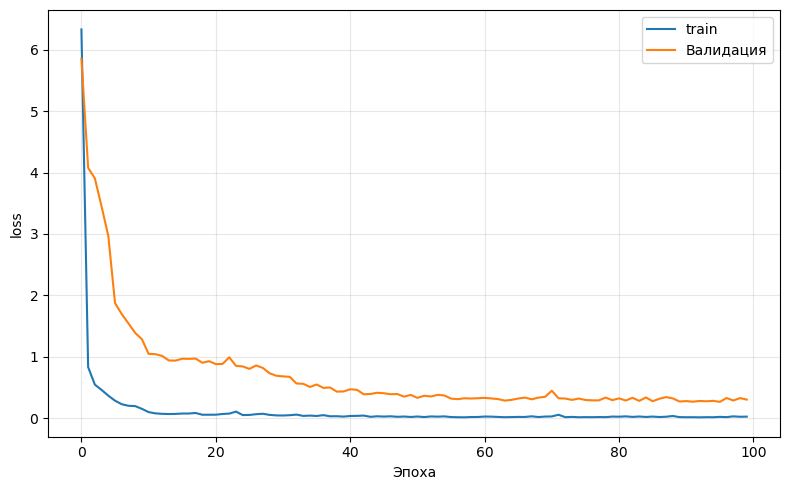

In [23]:
TrainingPlotter.losses(history)

График обучения показывает устойчивое уменьшение функции потерь как на обучающей, так и на val выборках, что свидет-ет о корректном процессе обучения модели и отсутствии расходимости.

При этом итоговое значение функции потерь на val выборке примерно в 13 раз превышает значение на обучающей.

Данное расхождение объясняется особенностью формирования выборок. Исходный набор данных представляет собой непрерывную запись длительностью около 24 часов, после чего был разделен по времени: первые 80% наблюдений использовались для обучения, а последние 20% для валидации.

Таким образом, val выборка содержит состояния системы, соот-ует другому временному интервалу суток, распределение признаков которого частично отличается от распределения, наблюдаемого при обучении. 

Поскольку запись охватывает только один суточный цикл, модель не имеет возможности заранее изучить режимы работы пользователя, что закономерно приводит к увеличению ошибки восстановления на валидационной выборке.

## Ошибки рекоснтуркции

In [24]:
evaluator = Evaluator(model)

### Вид реконструкции

In [25]:
def show(eval: Evaluator, loaders: dict[str, DataLoader], idx_batch: list[int] = [10]):

    for name, loader in loaders.items():
        orig, recon = eval.reconstruct(loader)

        fig, ax = plt.subplots(len(idx_batch), 1, figsize=(12,9))
        ax = ax.flatten()
        
        fig.suptitle(name, fontsize=14, fontweight='bold')

        for num_plot, idx in enumerate(idx_batch):
            sns.lineplot(data=orig[idx], label='Оригинал', ax=ax[num_plot])
            sns.lineplot(data=recon[idx], label='Реконструированный', ax=ax[num_plot])
            
        plt.legend()

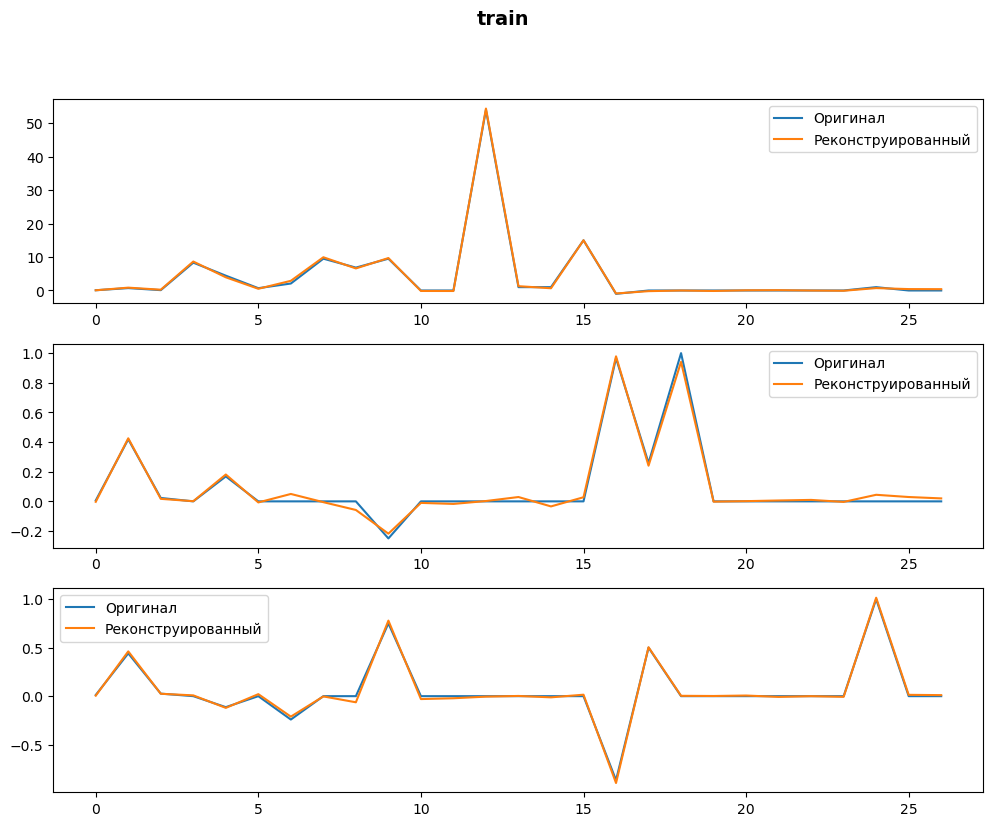

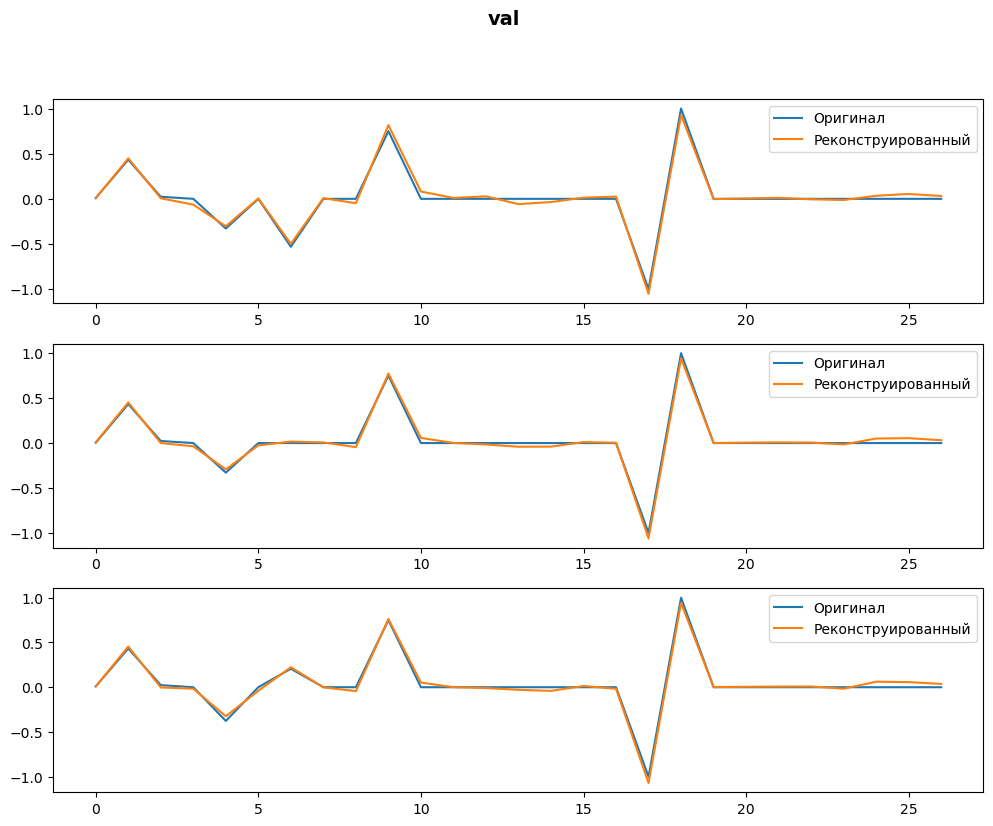

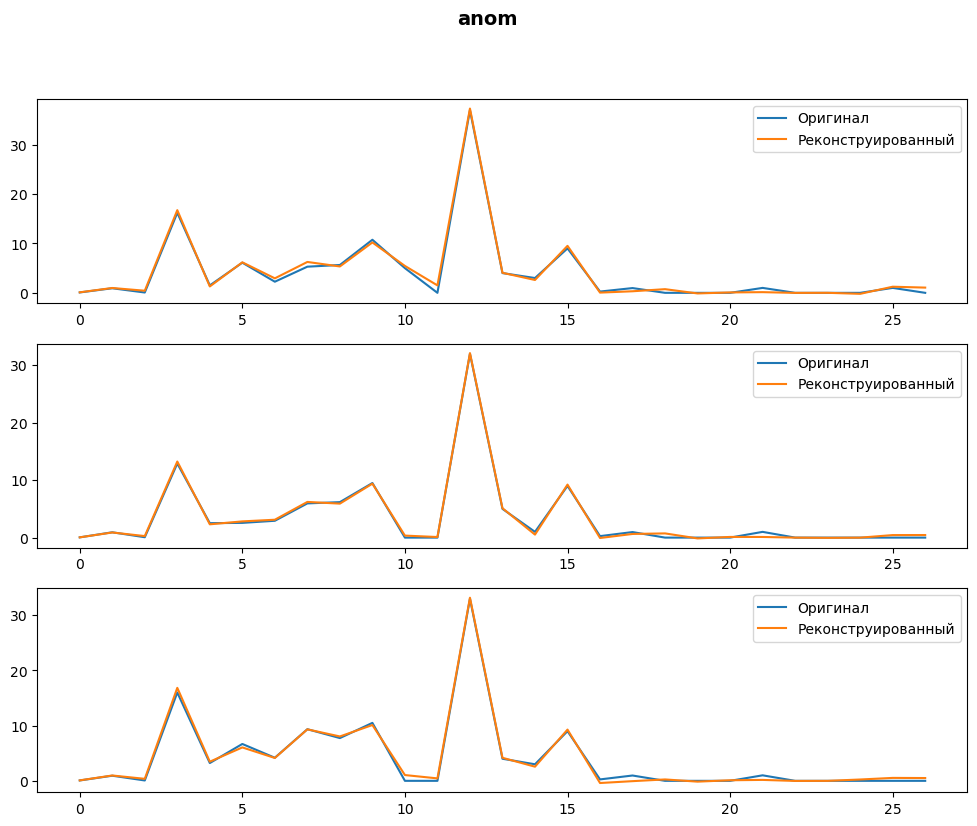

In [26]:
show(
    eval=evaluator,
    loaders={
        'train': train_loader,
        'val': val_loader,
        'anom': anom_loader
    },
    idx_batch=[7, 10, 8]

)

### Распределение ошибок

In [ ]:
def show(eval: Evaluator, loaders: dict[str, DataLoader]):

    eps = 1e-8

    plt.figure(figsize=(10,6))

    stats = {}

    for name, loader in loaders.items():

        loader_error = eval.reconstruction_errors(loader)

        sns.kdeplot(np.log10(loader_error + eps), label=name, fill=True)

        stats[name] = pd.Series(loader_error).describe()

    plt.xlabel("log10(ошибки восстановления)")
    plt.grid(alpha=0.3)
    plt.legend()

    stats = pd.DataFrame(stats).T.round(4)

    display(stats)

,count,mean,std,min,25%,50%,75%,max
train,13796.0,0.0187,0.0707,0.0002,0.0006,0.0008,0.0035,5.1250
val,3451.0,0.3089,1.5745,0.0008,0.1281,0.1679,0.2177,46.1180
anom,209.0,4.3356,10.7239,0.1041,0.2622,0.4524,2.5691,66.0641


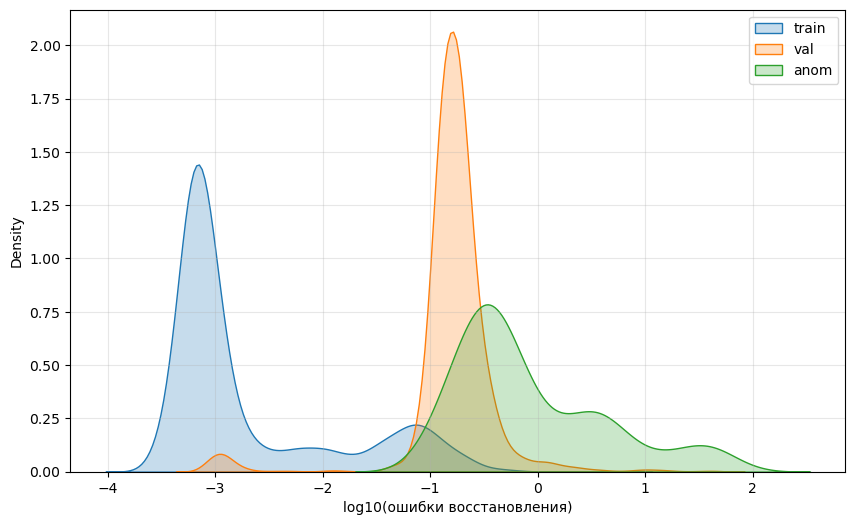

In [28]:
show(
    eval=evaluator,
    loaders={
        'train': train_loader,
        'val': val_loader,
        'anom': anom_loader
    },
)

Анализ распределений ошибок реконструкции показывает, что автоэнкодер успешно разделяет нормальные и аномальные наблюдения. 

Для аномальных объектов характерны существенно большие значения ошибки реконструкции, что подтверждает способность модели выявлять ранее неизвестные отклонения. При этом между распределениями нормальных и аномальных наблюдений сохраняется небольшая область пересечения. 

Подобное поведение можно считать ожидаемым , поскольку часть аномальных состояний лишь незначительно отличается от нормального поведения, тогда как некоторые нормальные состояния могут представлять ранее не наблюдавшиеся режимы активности пользователя. 

Вследствие этого окончательное решение о принадлежности объекта к аномальному классу принимается на основе выбранного порога ошибки реконструкции, определяющего компромисс между ложными срабатываниями и пропусками аномалий.

## Оптимизация модели по слоям

In [20]:
def compare_autoencoders(
    architectures,
    input_dim,
    train_loader,
    val_loader,
    epochs=100,
    lr=1e-3,
):

    results = []
    histories = {}

    for hidden_dims in architectures:

        print(f"\nАрхитектура: {hidden_dims}")

        model = AutoEncoder(
            input_dim=input_dim,
            hidden_dims=hidden_dims
        )

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=lr
        )

        trainer = Trainer(
            model=model,
            optimizer=optimizer,
        )

        history = trainer.fit(
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=epochs
        )

        histories[str(hidden_dims)] = history.val_loss

        params = sum(p.numel() for p in model.parameters())

        results.append({
            "hidden_dims": str(hidden_dims),
            "parameters": params,
            "train_loss": history.train_loss[-1],
            "val_loss": history.val_loss[-1],
            "ratio": history.val_loss[-1] / history.train_loss[-1]
        })

    results = (
        pd.DataFrame(results)
        .sort_values("val_loss")
        .reset_index(drop=True)
    )

    plt.figure(figsize=(11,6))

    for name, loss in histories.items():
        sns.lineplot(
            x=np.arange(1, len(loss)+1),
            y=loss,
            label=name,
            linewidth=2
        )

    plt.xticks(np.arange(0, epochs + 1, 5))

    all_losses = np.concatenate([histories[k] for k in histories])

    plt.ylim(
        np.percentile(all_losses, 5),
        np.percentile(all_losses, 100) * 1.05
    )

    plt.xlabel("Эпоха")
    plt.ylabel("Val loss")

    plt.grid(alpha=0.3)
    plt.legend(title="скрытаые слои")

    plt.tight_layout()
    plt.show()

    return results


Архитектура: [64, 16]
Epoch 001 | train=9.066391 | val=7.430475
Epoch 002 | train=0.906771 | val=3.961277
Epoch 003 | train=0.510941 | val=3.373231
Epoch 004 | train=0.370138 | val=2.979594
Epoch 005 | train=0.280543 | val=2.381579
Epoch 006 | train=0.211672 | val=1.850031
Epoch 007 | train=0.144343 | val=1.551405
Epoch 008 | train=0.098490 | val=1.036915
Epoch 009 | train=0.076483 | val=0.970964
Epoch 010 | train=0.069010 | val=0.920770
Epoch 011 | train=0.067212 | val=0.877699
Epoch 012 | train=0.062511 | val=0.839791
Epoch 013 | train=0.061769 | val=0.773529
Epoch 014 | train=0.059658 | val=0.741124
Epoch 015 | train=0.055327 | val=0.678434
Epoch 016 | train=0.051238 | val=0.618059
Epoch 017 | train=0.047663 | val=0.577433
Epoch 018 | train=0.044865 | val=0.526398
Epoch 019 | train=0.038523 | val=0.486834
Epoch 020 | train=0.036168 | val=0.468943
Epoch 021 | train=0.033562 | val=0.433383
Epoch 022 | train=0.032427 | val=0.459626
Epoch 023 | train=0.032263 | val=0.438396
Epoch 024 |

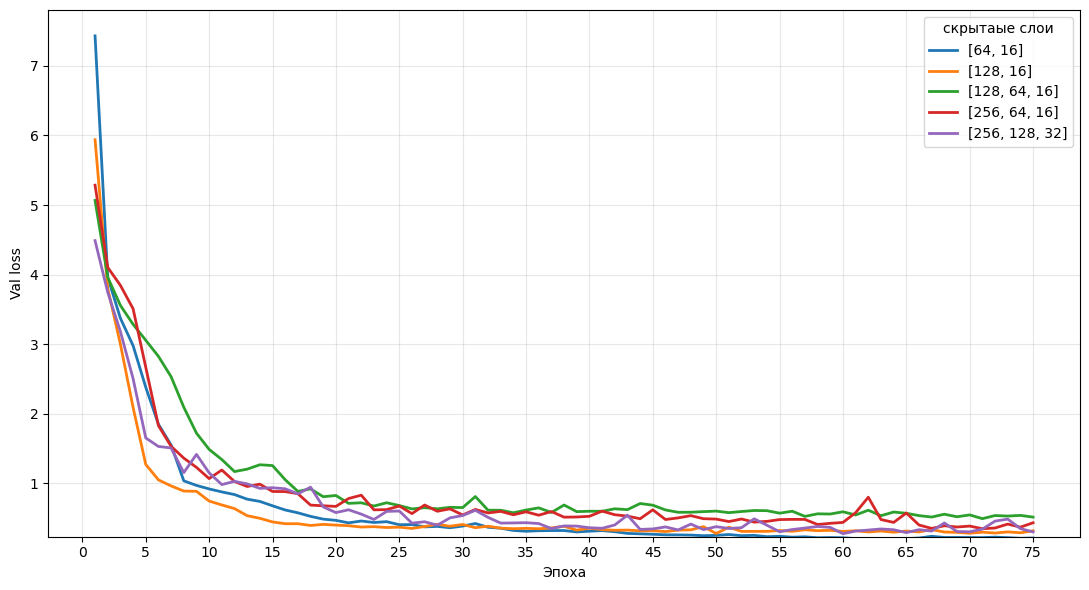

,hidden_dims,parameters,train_loss,val_loss,ratio
0,"[64, 16]",5675,0.005629,0.215050,38.201351
1,"[256, 128, 32]",88379,0.011227,0.303363,27.020099
2,"[128, 16]",11307,0.008919,0.318760,35.741336
3,"[256, 64, 16]",49323,0.019917,0.434490,21.814594
4,"[128, 64, 16]",25771,0.027194,0.515769,18.966510


In [21]:
architectures = [
    [64, 16],
    [128, 16],
    [128, 64, 16],
    [256, 64, 16],
    [256, 128, 32],
]

compare_autoencoders(
    architectures=architectures,
    input_dim=X_train.shape[1],
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=75,
)

лДя выбора архитектуры автоэнкодера было проведено сравнение нескольких вариантов с различным числом скрытых слоев и параметров. Критерием выбора являлось значение функции потерь на валидационной выборке

Эксперимент показал, что наилучший результат продемон-ала наиболее компактная архитектура [64, 16]. Данная модель обеспечила минимальную ошибку реконструкции при одновременном использовании наименьшего кол-ва параметров.

Увеличение глубины сети не приводило к улчш-ию кач-ва, а наоборот, оно падало с усложнением модели.

Epoch 001 | train=7.313118 | val=5.925931
Epoch 002 | train=0.940670 | val=4.005274
Epoch 003 | train=0.528752 | val=3.459490
Epoch 004 | train=0.426606 | val=2.903540
Epoch 005 | train=0.364564 | val=2.491901
Epoch 006 | train=0.305167 | val=1.971963
Epoch 007 | train=0.253488 | val=1.498808
Epoch 008 | train=0.210714 | val=1.265211
Epoch 009 | train=0.158073 | val=1.085842
Epoch 010 | train=0.122124 | val=0.899829
Epoch 011 | train=0.090708 | val=0.823804
Epoch 012 | train=0.075099 | val=0.788451
Epoch 013 | train=0.069762 | val=0.725786
Epoch 014 | train=0.070330 | val=0.757965
Epoch 015 | train=0.070794 | val=0.766370
Epoch 016 | train=0.060668 | val=0.750396
Epoch 017 | train=0.050383 | val=0.708858
Epoch 018 | train=0.045131 | val=0.704953
Epoch 019 | train=0.042021 | val=0.712399
Epoch 020 | train=0.039742 | val=0.723248
Epoch 021 | train=0.036926 | val=0.708679
Epoch 022 | train=0.036843 | val=0.672822
Epoch 023 | train=0.034181 | val=0.677903
Epoch 024 | train=0.034425 | val=0

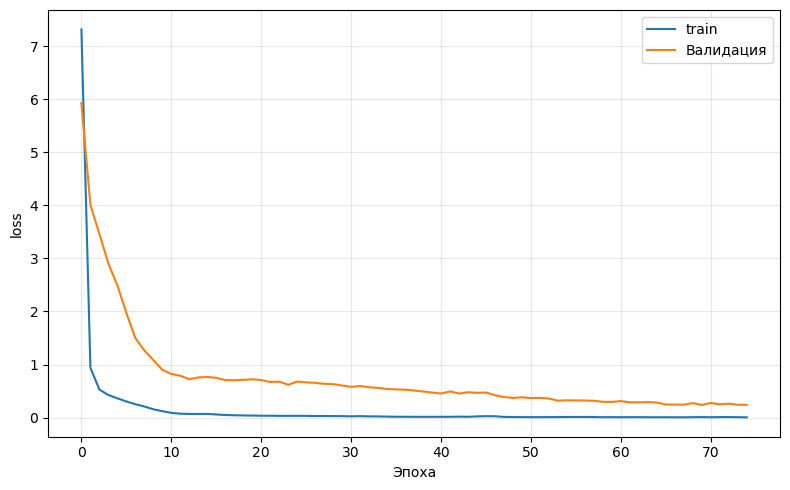

In [38]:
model = AutoEncoder(
    input_dim=X_train.shape[1],
    hidden_dims=[64, 16]
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

trainer = Trainer(
    model,
    optimizer,
)
history = trainer.fit(
    train_loader,
    val_loader,
    epochs=75
)
TrainingPlotter.losses(history)

## Итоги структуры модели

- Архитектруа: 64 - 16 - 64

- Функция активации: RELU

- Dropout: False

- BatchNorm: False

- Функция потерь: MSE

- Оптимизатор: Adam

- kearning rate: 0.001

- Batch size: 256

- кол-во эпох: 75